# PREDICTIVE ML MODEL TRAINING FOR HYDRAULIC PRESS THROUGH SYNTHETICALLY GENERATED DATASET

### Set-up & Imports

In [1]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import gc
import json
import math
import joblib
import onnxmltools
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloatTensorType
from skl2onnx.common.data_types import FloatTensorType as Skl2OnnxFloatTensorType
from onnxmltools.utils import save_model as save_onnx_model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score
from IPython.display import display
from scipy.stats import spearmanr
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from scipy.stats import ks_2samp



# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def free_memory(variable_names: list):
    """Free memory by deleting variables and running garbage collector."""
    for var_name in variable_names:
        if var_name in globals():
            try:
                del globals()[var_name]
            except Exception:
                pass
    gc.collect()

# HYDRAULIC PRESS SPECIFIC CONSTANTS
    # These constants are tuned for Hydraulic Press RUL scale (30K-50K min range)
    # Similar to Process Pump scale for optimal ML performance
STAGE1_CRITICAL_THRESHOLD = 300    # Stage-1 classifier trigger (minutes) 5 hours
STAGE2A_CRITICAL_THRESHOLD = 200   # Stage-2A regressor max RUL (minutes) ~3.3 hours
PROJECT_CRITICAL_THRESHOLD = 100   # Final project metric threshold (minutes) ~1.6 hours
ACCURACY_TOLERANCE = 10            # +/- 10 min tolerance (same as Process Pump)
SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]

# Create models directory if it doesn't exist
if not os.path.exists("models_and_features"):
    os.makedirs("models_and_features")
    if not os.path.exists("models_and_features/hydraulic_press"):
        os.makedirs("models_and_features/hydraulic_press")
    if not os.path.exists("models_and_features") or not os.path.exists("models_and_features/hydraulic_press"):
        raise RuntimeError("Failed to create models_and_features directory")

save_path= "models_and_features/hydraulic_press/"

print_footer("SETUP AND IMPORTS COMPLETE")



----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [2]:
# 1/ Dataset Load & Basic Inspection
# Memory-optimized: Load directly to pandas, avoid duplicate copies

print_header("1/ DATASET LOAD")

# Define file paths
long_life_csv_path = "synthetic_hydraulic_press_data_long_life.csv"
short_life_csv_path = "synthetic_hydraulic_press_data_short_life.csv"

# Load datasets with optimized dtypes to save memory
dtype_mapping = {
                    'cycle_id': 'int32',
                    'time_min': 'int32',
                    'total_rul': 'int32',
                    'current_rul': 'int32',
                    'hydraulic_pressure': 'float32',
                    'oil_temperature': 'float32',
                    'oil_contamination': 'float32',
                    'ram_position_deviation': 'float32',
                    'press_force': 'float32',
                    'vibration': 'float32',
                    'flow_rate': 'float32',
                    'motor_current': 'float32'
                }

print("Loading Long-Life dataset...")
df_long_life = pd.read_csv(long_life_csv_path, dtype=dtype_mapping)

print("Loading Short-Life dataset...")
df_short_life = pd.read_csv(short_life_csv_path, dtype=dtype_mapping)

# Print dataset info
print("\n--- Long-Life Dataset")
print(f"Shape: {df_long_life.shape}")
print(f"Memory: {df_long_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_long_life['current_rul'].min()} - {df_long_life['current_rul'].max()} minutes")
print(f"Cycles: {df_long_life['cycle_id'].nunique()}")

print("\n--- Short-Life Dataset")
print(f"Shape: {df_short_life.shape}")
print(f"Memory: {df_short_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_short_life['current_rul'].min()} - {df_short_life['current_rul'].max()} minutes")
print(f"Cycles: {df_short_life['cycle_id'].nunique()}")

# Critical region analysis
long_critical_ratio = (df_long_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100
short_critical_ratio = (df_short_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100

print(f"\n--- Critical Region (RUL <= {PROJECT_CRITICAL_THRESHOLD})")
print(f"Long-Life: {long_critical_ratio:.4f}%")
print(f"Short-Life: {short_critical_ratio:.2f}%")

print_footer("DATASET LOAD COMPLETE")


1/ DATASET LOAD
Loading Long-Life dataset...
Loading Short-Life dataset...

--- Long-Life Dataset
Shape: (25456356, 12)
Memory: 1221.9 MB
RUL range: 0 - 713374 minutes
Cycles: 80

--- Short-Life Dataset
Shape: (468769, 12)
Memory: 22.5 MB
RUL range: 0 - 4993 minutes
Cycles: 200

--- Critical Region (RUL <= 100)
Long-Life: 0.0317%
Short-Life: 4.31%

----------------------------------------------------------------------
DATASET LOAD COMPLETE
----------------------------------------------------------------------


In [3]:
# 1A/ Long-Life Dataset Summary
print_header("1A/ LONG-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_long_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_long_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_long_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_long_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_long_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_long_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_long_life['total_rul'].min()}")
print(f"Max total_rul: {df_long_life['total_rul'].max()}")

print_footer("LONG-LIFE DATASET SUMMARY COMPLETE")


1A/ LONG-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:
                            count        mean         std       min         25%         50%         75%         max
cycle_id                2.546e+07      41.187      23.709     1.000      20.000      44.000      61.000      80.000
time_min                2.546e+07  228553.933  171587.926     0.000   84824.000  191668.000  342948.000  713374.000
total_rul               2.546e+07  457108.866  189973.994  7014.000  308675.000  506910.000  640877.000  713375.000
curren

In [4]:
# 1B/ Short-Life Dataset Summary
print_header("1B/ SHORT-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_short_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_short_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_short_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_short_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_short_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_short_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_short_life['total_rul'].min()}")
print(f"Max total_rul: {df_short_life['total_rul'].max()}")

print_footer("SHORT-LIFE DATASET SUMMARY COMPLETE")


1B/ SHORT-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:
                           count      mean       std      min       25%       50%       75%       max
cycle_id                468769.0    99.743    60.068    1.000    43.000   101.000   154.000   200.000
time_min                468769.0  1609.984  1181.269    0.000   621.000  1372.000  2417.000  4993.000
total_rul               468769.0  3220.969  1261.952  139.000  2157.000  3412.000  4403.000  4994.000
current_rul             468769.0  1609.984  1181.269    0.000

## 2) Explanatory Data Analysis (EDA)


2/ EXPLORATORY DATA ANALYSIS
Selected cycles for Short-Life Dataset: [16, 31, 96, 159]


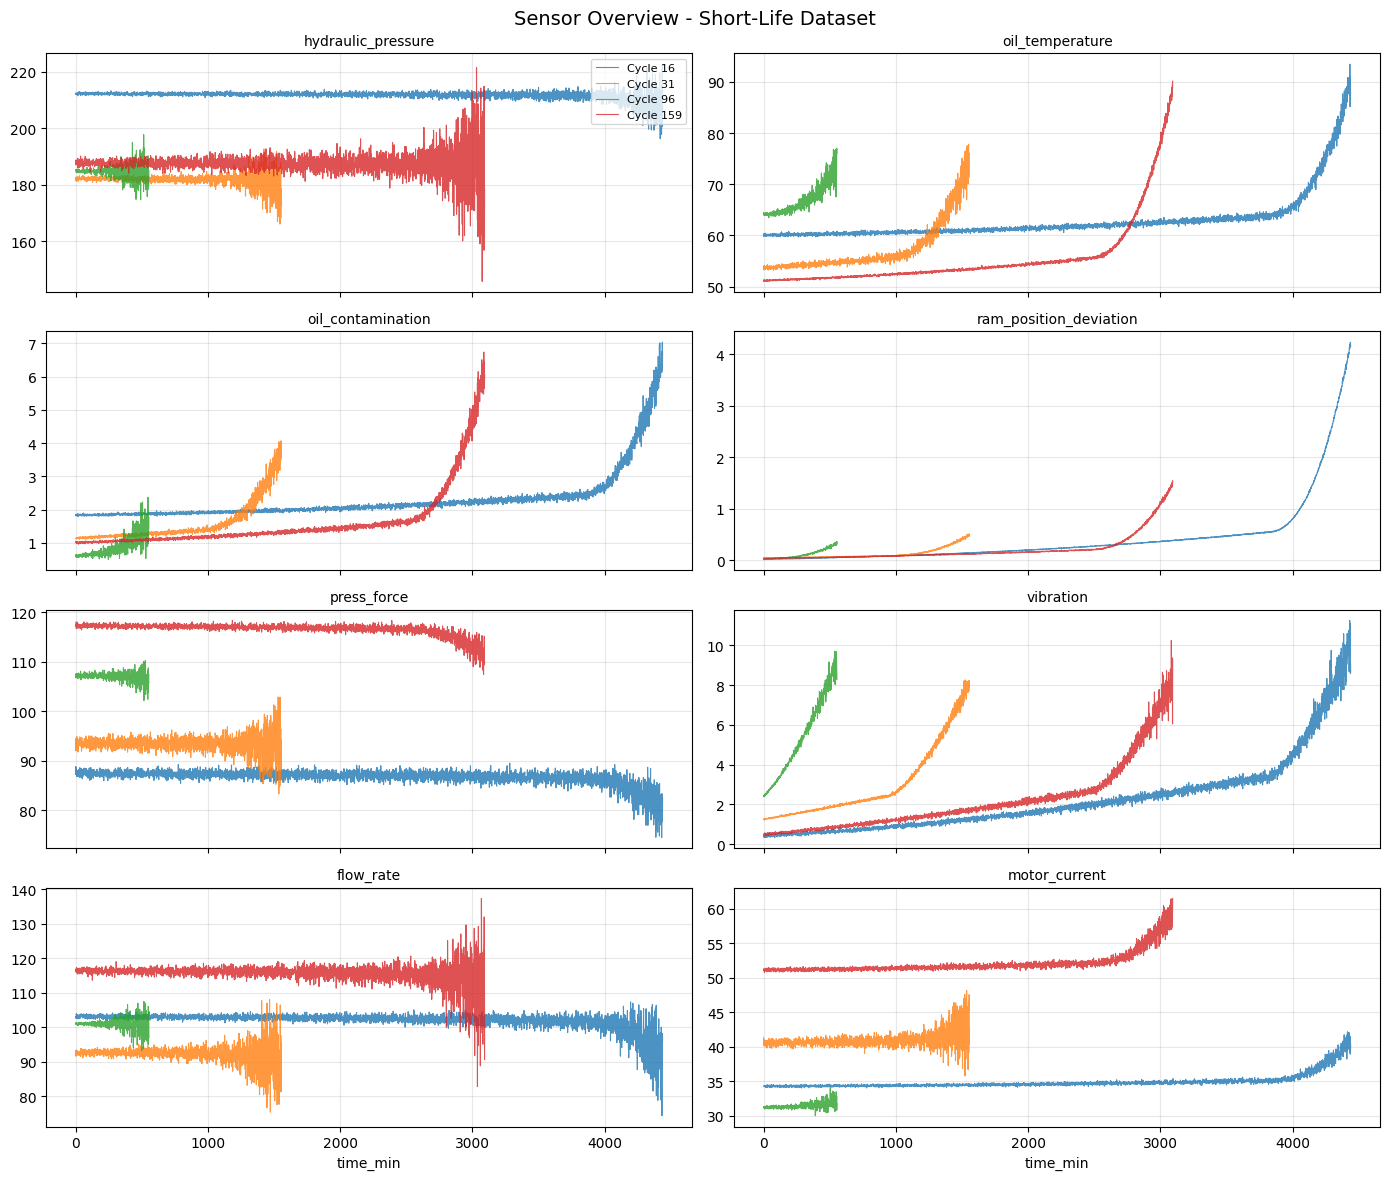


Sampling Long-Life dataset for visualization...
Selected cycles for Long-Life Dataset (Sampled): [13, 58, 62, 75]


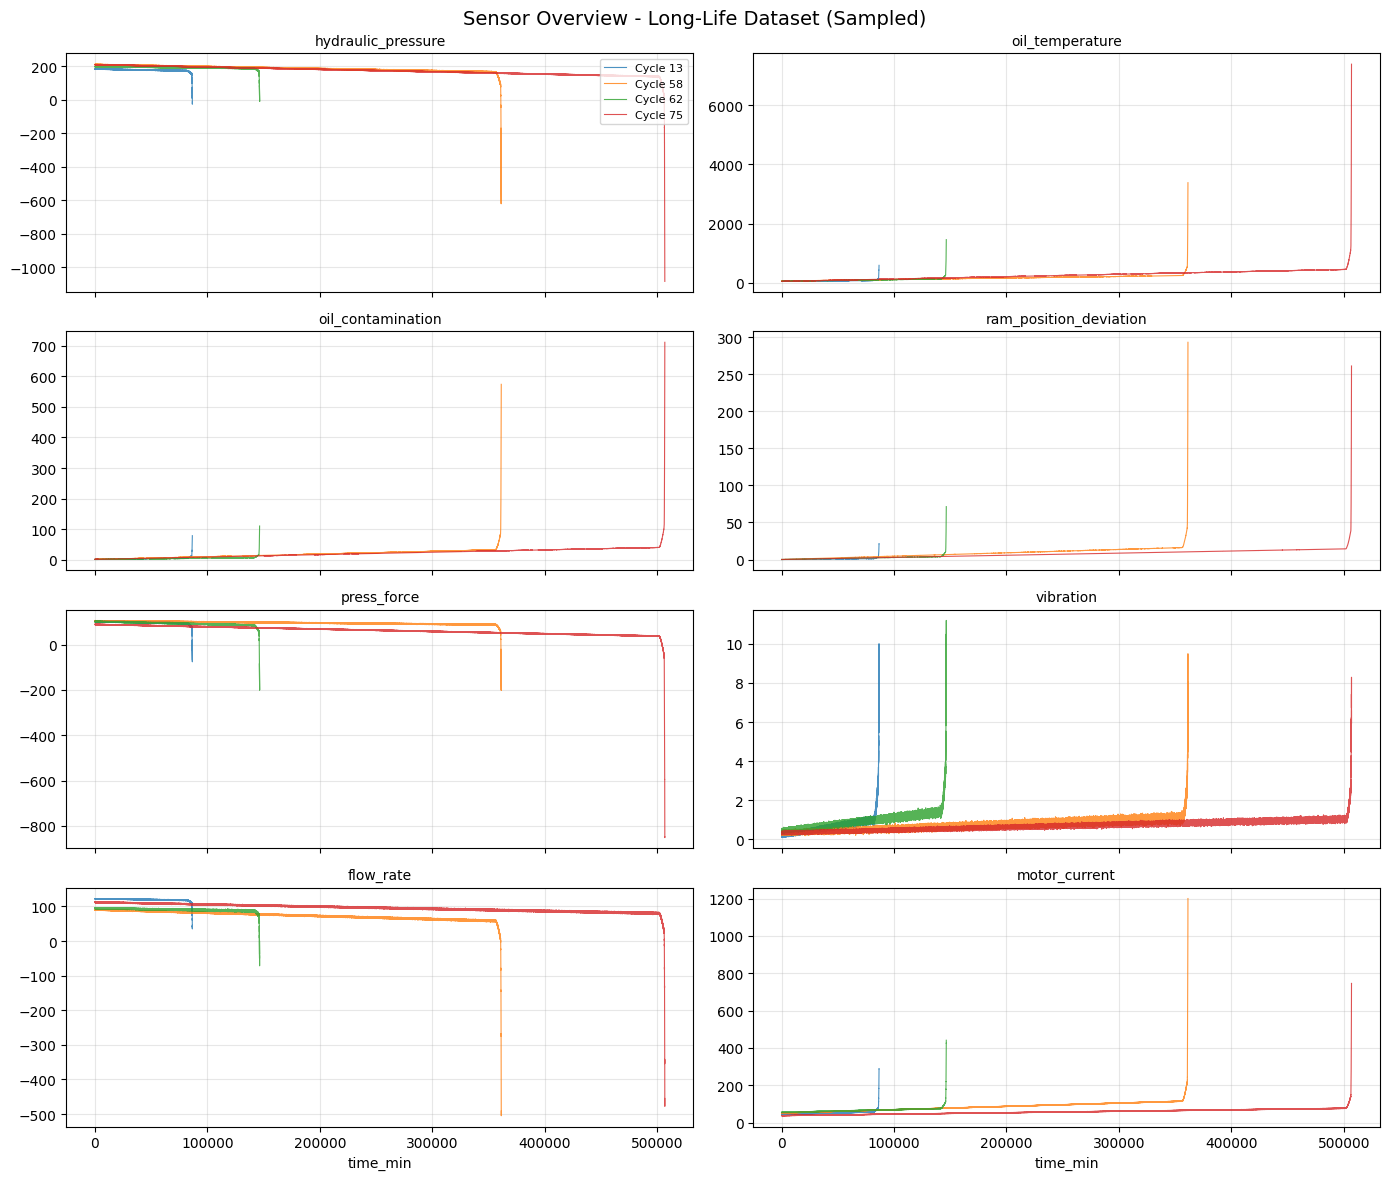


----------------------------------------------------------------------
EDA COMPLETE
----------------------------------------------------------------------


In [5]:
# 2/ Exploratory Data Analysis - Sensor Overview
print_header("2/ EXPLORATORY DATA ANALYSIS")

def plot_sensor_overview(dataframe, dataset_name):
    """Plot sensor trends for selected cycles."""
    
    # Select 4 random cycles for visualization
    np.random.seed(42)
    all_cycles = sorted(dataframe['cycle_id'].unique())
    selected_cycles = sorted(np.random.choice(all_cycles, size=min(4, len(all_cycles)), replace=False))
    
    print(f"Selected cycles for {dataset_name}: {selected_cycles}")
    
    # Create subplot grid
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    
    colors = plt.cm.tab10.colors[:4]
    
    for sensor_idx, sensor_name in enumerate(SENSOR_COLUMNS):
        ax = axes[sensor_idx]
        
        for cycle_idx, cycle_id in enumerate(selected_cycles):
            cycle_data = dataframe[dataframe['cycle_id'] == cycle_id].sort_values('time_min')
            ax.plot(
                    cycle_data['time_min'], 
                    cycle_data[sensor_name], 
                    label=f'Cycle {cycle_id}',
                    color=colors[cycle_idx],
                    linewidth=0.8,
                    alpha=0.8
                )
        
        ax.set_title(sensor_name, fontsize=10)
        ax.grid(alpha=0.3)
    
    # Add legend to first subplot
    axes[0].legend(loc='upper right', fontsize=8)
    
    # Set common x-label
    for ax in axes[-2:]:
        ax.set_xlabel('time_min')
    
    fig.suptitle(f'Sensor Overview - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for Short-Life (smaller dataset, faster to plot)
plot_sensor_overview(df_short_life, "Short-Life Dataset")

# Sample Long-Life for faster plotting
print("\nSampling Long-Life dataset for visualization...")
sample_cycles = np.random.choice(df_long_life['cycle_id'].unique(), size=4, replace=False)
df_long_sample = df_long_life[df_long_life['cycle_id'].isin(sample_cycles)]
plot_sensor_overview(df_long_sample, "Long-Life Dataset (Sampled)")

# Clean up sample
del df_long_sample
gc.collect()

print_footer("EDA COMPLETE")

### 2A) Additional EDA: RUL, Correlation & Distributions


2A/ CORRELATION ANALYSIS
Short-Life Dataset Correlations:


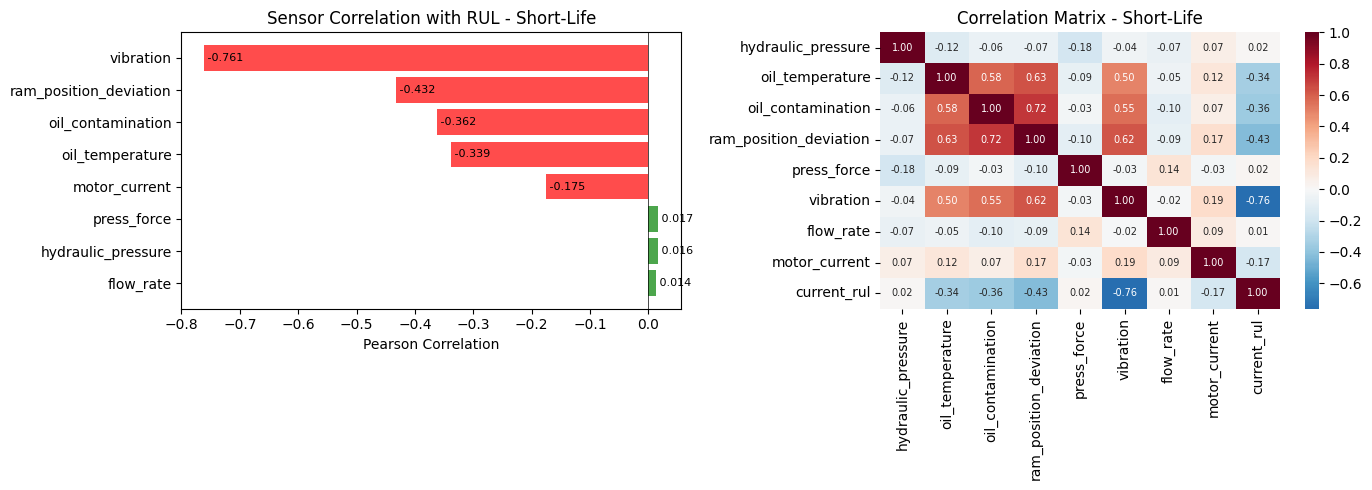

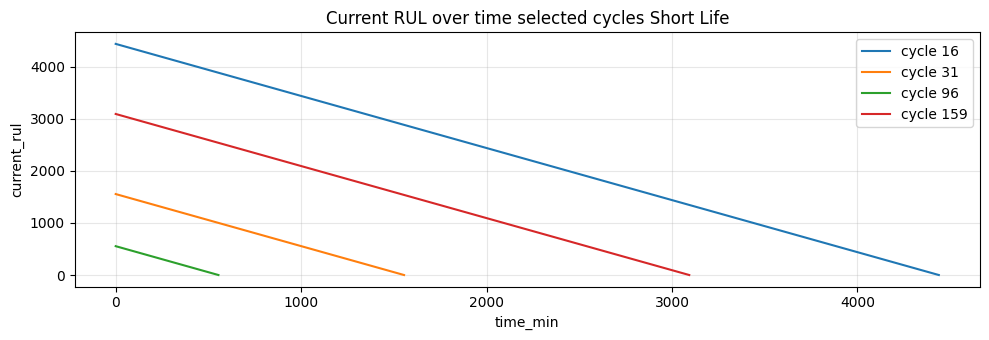


Long-Life Dataset Correlations (sampled):


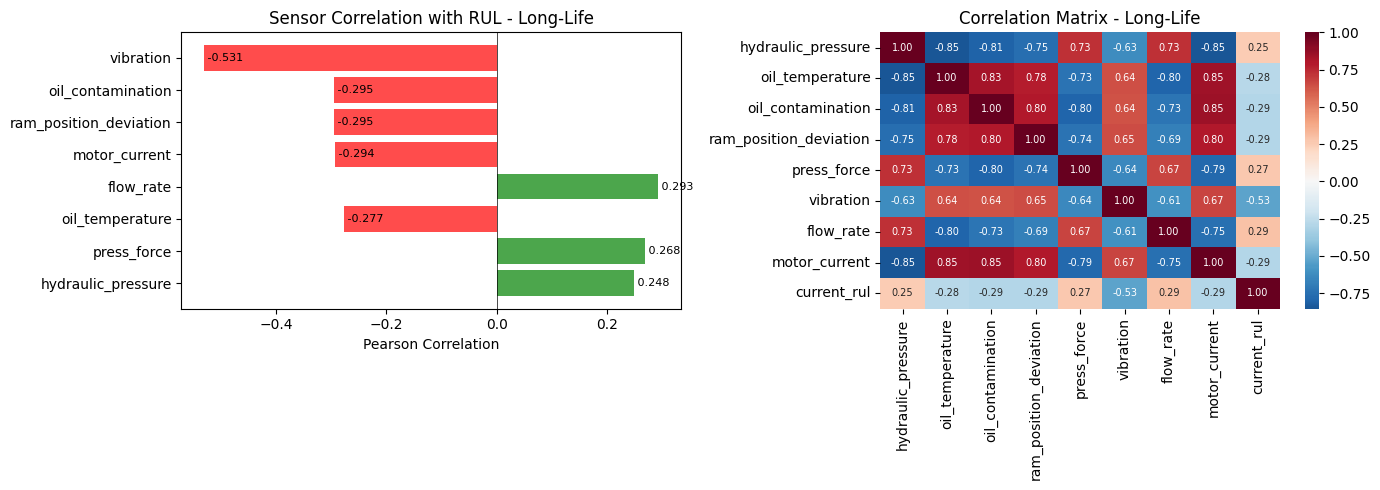

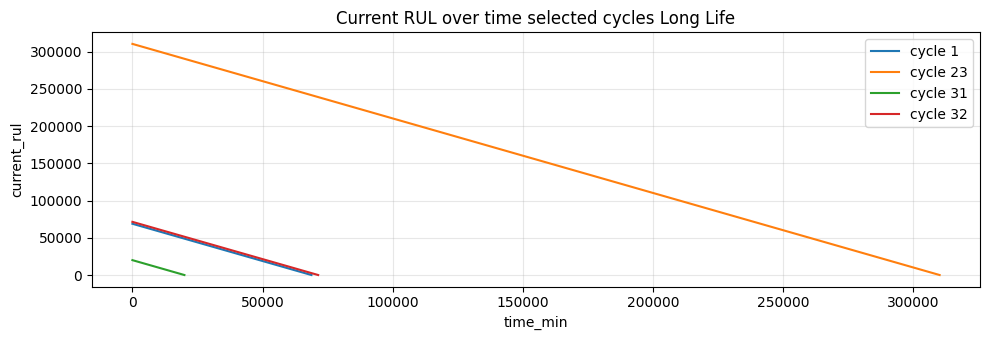


----------------------------------------------------------------------
CORRELATION ANALYSIS COMPLETE
----------------------------------------------------------------------


In [6]:
# 2A/ Correlation Analysis
print_header("2A/ CORRELATION ANALYSIS")

SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]


def plot_correlation_analysis(dataframe, dataset_name, sample_size=50000):
    """Plot correlation between sensors and RUL."""
    
    # Sample for memory efficiency
    if len(dataframe) > sample_size:
        df_sample = dataframe.sample(n=sample_size, random_state=42)
    else:
        df_sample = dataframe
    
    # Columns for correlation
    correlation_columns = SENSOR_COLUMNS + ['current_rul']
    
    # Calculate correlation matrix
    correlation_matrix = df_sample[correlation_columns].corr()
    
    # Extract RUL correlations
    rul_correlations = correlation_matrix['current_rul'].drop('current_rul')
    rul_correlations_sorted = rul_correlations.reindex(rul_correlations.abs().sort_values().index)
    
    # Plot correlation bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of RUL correlations
    ax1 = axes[0]
    colors = ['green' if x > 0 else 'red' for x in rul_correlations_sorted.values]
    ax1.barh(rul_correlations_sorted.index, rul_correlations_sorted.values, color=colors, alpha=0.7)
    ax1.set_xlabel('Pearson Correlation')
    ax1.set_title(f'Sensor Correlation with RUL - {dataset_name}')
    ax1.axvline(x=0, color='black', linewidth=0.5)
    
    for i, (sensor, corr) in enumerate(rul_correlations_sorted.items()):
        ax1.text(corr, i, f' {corr:.3f}', va='center', fontsize=8)
    
    # Heatmap
    ax2 = axes[1]
    sns.heatmap(
                    correlation_matrix, 
                    annot=True, 
                    fmt='.2f', 
                    cmap='RdBu_r', 
                    center=0,
                    ax=ax2,
                    annot_kws={'size': 7}
                )
    ax2.set_title(f'Correlation Matrix - {dataset_name}')
    
    plt.tight_layout()
    plt.show()
    
    return rul_correlations_sorted

def additional_eda(dataframe_input, title_suffix=""):
    if not isinstance(dataframe_input, pl.DataFrame):
        dataframe_polars = pl.from_pandas(dataframe_input)
    else:
        dataframe_polars = dataframe_input

    available_sensors = [sensor_name for sensor_name in SENSOR_COLUMNS if sensor_name in dataframe_polars.columns]

    if not available_sensors:
        print(f"No sensor columns available for 2A EDA {title_suffix}")
        return

    np.random.seed(42)
    unique_cycle_ids = sorted(dataframe_polars.get_column("cycle_id").unique().to_list())
    number_of_cycles = min(4, len(unique_cycle_ids))
    selected_cycle_ids = sorted(np.random.choice(unique_cycle_ids, size=number_of_cycles, replace=False))

    plt.figure(figsize=(10, 3.5))
    for cycle_id in selected_cycle_ids:
        cycle_subset = dataframe_polars.filter(pl.col("cycle_id") == cycle_id).sort("time_min")
        plt.plot(
                    cycle_subset.get_column("time_min").to_numpy(),
                    cycle_subset.get_column("current_rul").to_numpy(),
                    label=f'cycle {cycle_id}',
                    linewidth=1.5
                )
    plt.xlabel('time_min')
    plt.ylabel('current_rul')
    plt.title(f'Current RUL over time selected cycles {title_suffix}')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



# Analyze Short-Life dataset
print("Short-Life Dataset Correlations:")
short_correlations = plot_correlation_analysis(df_short_life, "Short-Life")
additional_eda(df_short_life, title_suffix="Short Life")

# Analyze Long-Life dataset (sampled)
print("\nLong-Life Dataset Correlations (sampled):")
long_correlations = plot_correlation_analysis(df_long_life, "Long-Life")
additional_eda(df_long_life, title_suffix="Long Life")

print_footer("CORRELATION ANALYSIS COMPLETE")

### 2B) Cycle-to-cycle comparison (start vs end)

2B/ CYCLE COMPARISONS - start vs end summaries and plots

Example start/end table (Short Life) (first 8 cycles - sample sensors):


,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,209.624,59.875,0.915,0.027,184.611,140.775,9.467,4.821
1,2,202.071,58.571,0.946,0.011,209.321,59.644,1.535,0.157
2,3,197.062,60.941,1.085,0.045,204.117,81.315,4.131,1.711
3,4,194.008,59.038,0.764,0.033,179.453,81.992,1.912,0.877
4,5,205.185,64.868,1.076,0.020,208.685,118.011,5.000,1.379
5,6,216.151,60.881,0.930,0.041,207.470,124.691,7.214,4.693
6,7,204.304,50.754,0.572,0.032,191.750,120.893,6.559,4.694
7,8,213.882,56.291,1.706,0.039,225.347,75.414,3.872,0.981



Delta summary (Short Life) (end - start):
                              count    mean     std     min     25%     50%     75%     max
hydraulic_pressure_delta      200.0  -5.387  12.964 -43.645 -13.806  -4.717   3.082  45.662
oil_temperature_delta         200.0  27.284  20.075  -0.652  11.631  23.056  38.614  89.584
oil_contamination_delta       200.0   2.736   1.985  -0.271   1.253   2.440   3.678   8.579
ram_position_deviation_delta  200.0   1.490   1.201   0.088   0.557   1.111   2.108   5.254
press_force_delta             200.0  -3.114   3.852 -16.571  -5.745  -3.264  -0.526   8.816
vibration_delta               200.0   7.434   1.969   1.751   6.009   7.415   8.874  11.986
flow_rate_delta               200.0  -3.638   8.676 -27.890  -9.339  -4.378   2.298  20.456
motor_current_delta           200.0   5.675   4.458  -5.042   2.323   5.070   8.523  19.012


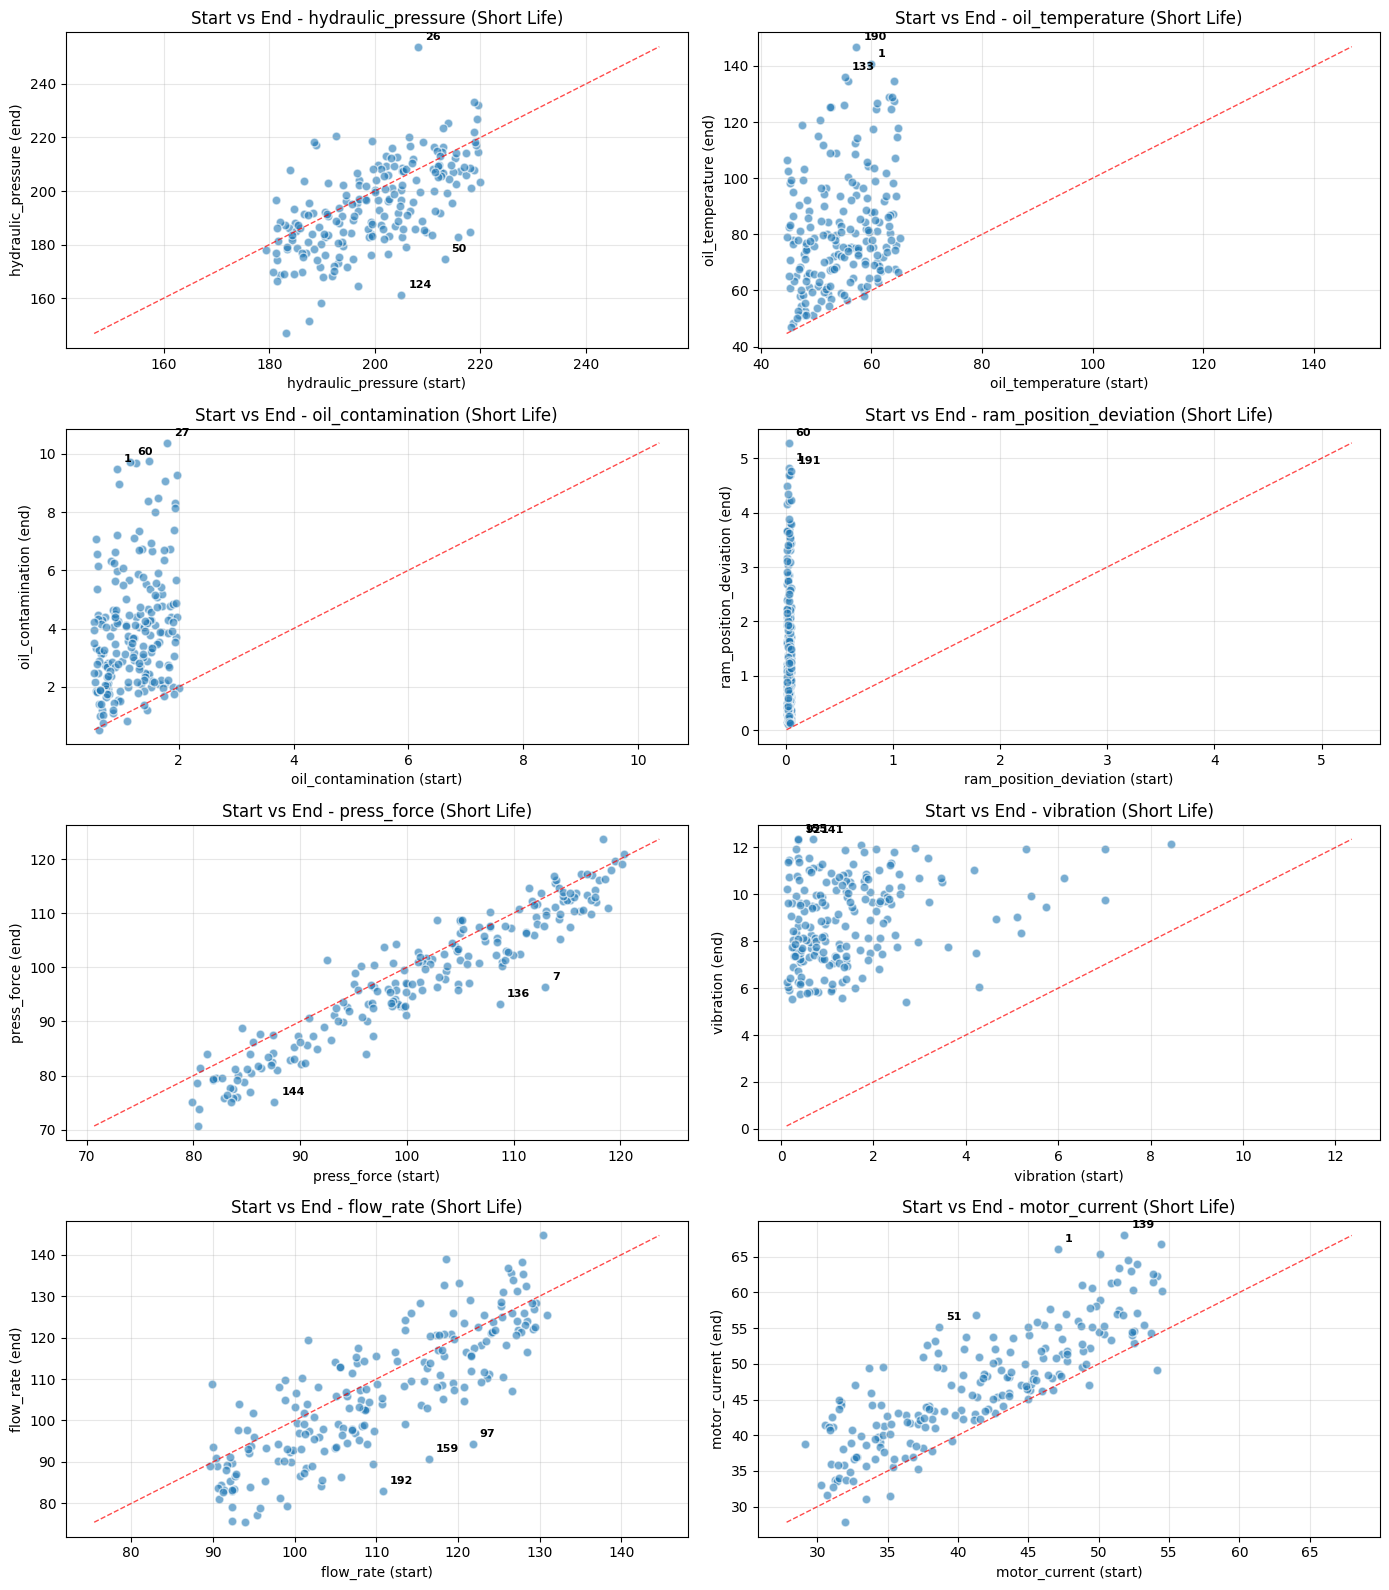


Top Extremes per Sensor ((Short Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       26             208.210                 253.872                    45.662
      168             188.462                 218.149                    29.686
      162             188.849                 217.099                    28.250
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
      124             205.011                 161.366                   -43.645
       50             213.229                 174.780                   -38.448
      175             183.123                 146.840                   -36.283

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
      190           57.280              146.864                 89.584
      133           55.190              136.147            

,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,197.278,46.917,1.686,0.025,47.122,1260.999,49.728,69.759
1,2,192.597,59.441,1.778,0.051,-975.582,8884.533,511.143,106.347
2,3,197.392,55.834,0.989,0.032,-1044.622,7601.489,488.789,510.361
3,4,214.741,55.321,0.954,0.033,-869.094,7276.625,1046.673,261.060
4,5,185.260,58.409,0.598,0.021,-1186.655,12083.851,1017.109,508.334
5,6,191.229,64.729,0.606,0.033,-916.771,9992.007,432.584,555.020
6,7,217.811,47.357,1.264,0.020,-234.806,3016.270,455.060,232.256
7,8,199.032,59.786,1.691,0.051,-13.825,510.942,113.219,39.633



Delta summary (Long Life) (end - start):
                              count      mean       std       min       25%       50%       75%        max
hydraulic_pressure_delta       80.0  -589.119   449.804 -1679.219  -970.090  -463.117  -211.532     -1.892
oil_temperature_delta          80.0  3745.575  2965.822   110.137  1435.135  3069.647  5318.438  12025.441
oil_contamination_delta        80.0   385.797   301.546     5.585   154.529   294.867   574.773   1199.817
ram_position_deviation_delta   80.0   186.748   150.014     2.370    74.117   132.442   262.281    639.812
press_force_delta              80.0  -479.083   387.740 -1465.163  -795.702  -331.032  -163.828    -10.952
vibration_delta                80.0     8.736     2.008     4.025     7.348     8.953    10.178     12.360
flow_rate_delta                80.0  -538.090   414.047 -1753.996  -764.537  -419.443  -218.998     -8.294
motor_current_delta            80.0   744.508   562.537    16.033   334.877   631.853  1090.830   2438

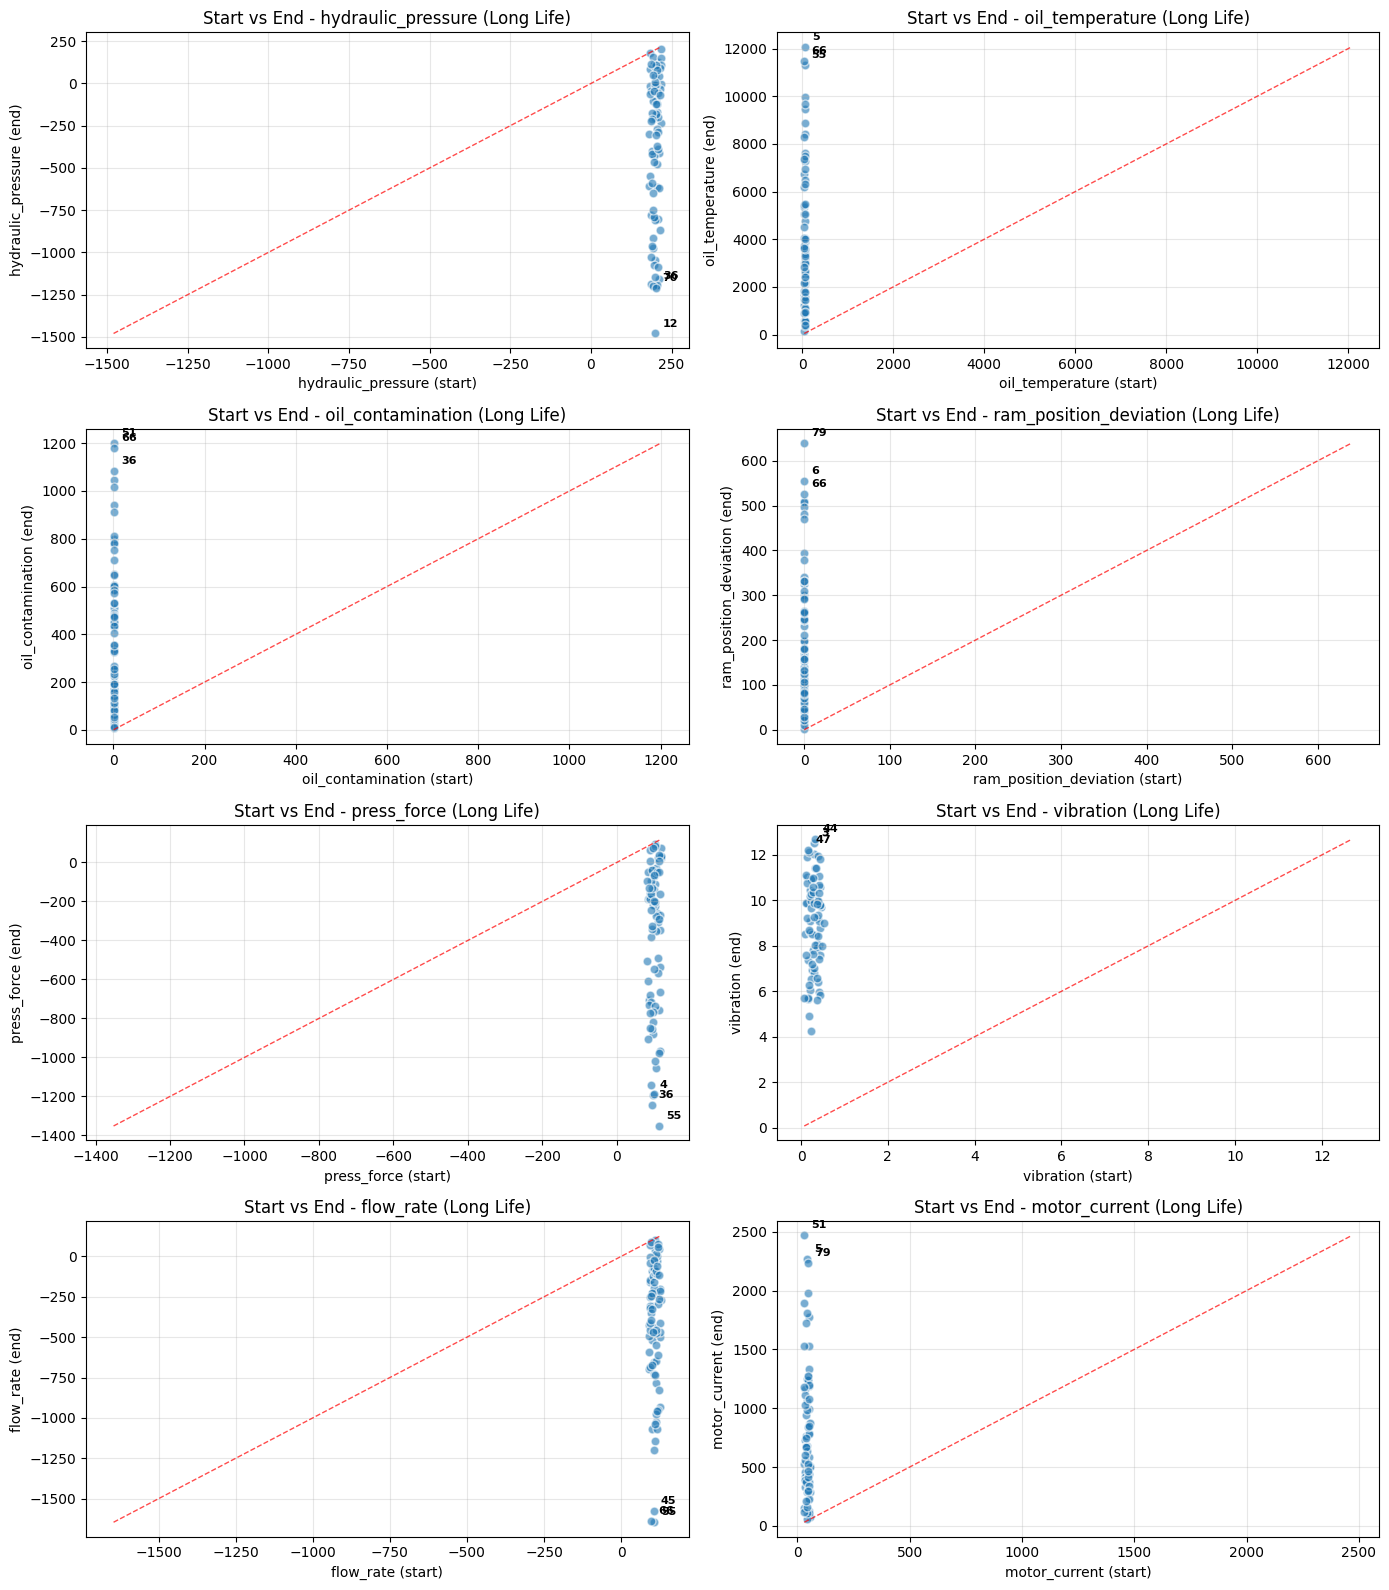


Top Extremes per Sensor ((Long Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       11             182.993                 181.101                    -1.892
       31             217.192                 203.358                   -13.834
       28             191.852                 157.332                   -34.520
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       12             199.775               -1479.443                 -1679.219
       70             201.017               -1211.518                 -1412.535
       36             202.340               -1198.630                 -1400.971

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
        5           58.409            12083.851              12025.441
       66           46.823            11497.672             

In [7]:
# 2B/ Cycle Comparisons - Start vs End Summaries and Plots
print("2B/ CYCLE COMPARISONS - start vs end summaries and plots")

def cycle_comparison(df_raw, title_suffix=""):
   
    # Determine sensor list
    if 'SENSOR_COLUMNS' in globals():
        sensors = SENSOR_COLUMNS
    else:
        sensors = [
                    "hydraulic_pressure", "oil_temperature", "oil_contamination",
                    "ram_position_deviation", "press_force", "vibration",
                    "flow_rate", "motor_current"
                ]

    # polars or pandas input
    try:
        is_pl = isinstance(df_raw, pl.DataFrame)
    except Exception:
        is_pl = False

    if is_pl:
        df_sorted = df_raw.sort(["cycle_id", "time_min"])
        firsts = df_sorted.groupby("cycle_id").first()
        lasts = df_sorted.groupby("cycle_id").last()
        # select only needed sensor cols that exist
        available_sensors = [s for s in sensors if s in df_raw.columns]
        cols_start = ["cycle_id"] + available_sensors
        cols_end = ["cycle_id"] + available_sensors
        start_end = firsts.select(cols_start).join(lasts.select(cols_end), on="cycle_id", how="inner", suffix="_end")
        # compute deltas and pct change using polars then convert to pandas for plotting
        for s in available_sensors:
            start_end = start_end.with_columns(
                                                    (pl.col(f"{s}_end") - pl.col(s)).alias(f"{s}_delta")
                                                ).with_columns(
                                                                ( (pl.col(f"{s}_delta") / pl.when(pl.col(s) == 0).then(None).otherwise(pl.col(s))) * 100 ).alias(f"{s}_pct_change")
                                                )
        start_end_pd = start_end.to_pandas()
    else:
        # pandas path
        df_sorted = df_raw.sort_values(["cycle_id", "time_min"])
        available_sensors = [s for s in sensors if s in df_raw.columns]
        if not available_sensors:
            print(f"No sensors found to compare {title_suffix}")
            return
        firsts = df_sorted.groupby("cycle_id").first().reset_index()
        lasts = df_sorted.groupby("cycle_id").last().reset_index()

        # build lasts_end by renaming only sensor columns
        lasts_end = lasts[["cycle_id"] + available_sensors].copy()
        lasts_end = lasts_end.rename(columns={s: f"{s}_end" for s in available_sensors})

        start_end_pd = pd.merge(
                                    firsts[["cycle_id"] + available_sensors],
                                    lasts_end,
                                    on="cycle_id",
                                    how="inner"
                                )

        # compute deltas and percent changes
        for s in available_sensors:
            start_end_pd[f"{s}_delta"] = start_end_pd[f"{s}_end"] - start_end_pd[s]
            start_end_pd[f"{s}_pct_change"] = start_end_pd[f"{s}_delta"] / start_end_pd[s].replace(0, np.nan) * 100.0


    # Basic display
    cols_show = ["cycle_id"] + available_sensors[:4] + [f"{s}_end" for s in available_sensors[:4]]
    print(f"\nExample start/end table {title_suffix} (first 8 cycles - sample sensors):")
    display(start_end_pd[cols_show].head(8))

    delta_cols = [f"{s}_delta" for s in available_sensors]
    print(f"\nDelta summary {title_suffix} (end - start):")
    print(start_end_pd[delta_cols].describe().T)

    # Plotting: dynamic grid (2 columns)
    n = len(available_sensors)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, s in enumerate(available_sensors):
        ax = axes[i]
        x = start_end_pd[s]
        y = start_end_pd[f"{s}_end"]
        ax.scatter(x, y, alpha=0.6, edgecolors="w", s=40)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "--", color="red", linewidth=1, alpha=0.7)
        ax.set_xlabel(f"{s} (start)")
        ax.set_ylabel(f"{s} (end)")
        ax.set_title(f"Start vs End - {s} {title_suffix}")
        ax.grid(alpha=0.3)

        # annotate top 3 absolute deltas
        top3_idx = start_end_pd[f"{s}_delta"].abs().nlargest(3).index
        for idx in top3_idx:
            row = start_end_pd.loc[idx]
            cid = int(row["cycle_id"])
            ax.annotate(
                            cid,
                            (row[s], row[f"{s}_end"]),
                            textcoords="offset points",
                            xytext=(5, 5),
                            fontsize=8,
                            fontweight="bold"
                        )

    # turn off unused axes
    for j in range(n, rows * cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    # Print top extremes for first three sensors
    print(f"\nTop Extremes per Sensor ({title_suffix})")
    for s in available_sensors[:3]:
        print(f"\nLargest increase in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nlargest(3, f"{s}_delta").to_string(index=False))
        print(f"Largest decrease in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nsmallest(3, f"{s}_delta").to_string(index=False))

    print(f"\n{'='*50}\nExplanatory Data Analysis COMPLETED {title_suffix}\n{'='*50}")


cycle_comparison(df_short_life, title_suffix="(Short Life)")
cycle_comparison(df_long_life, title_suffix="(Long Life)")

## 3) Train / Validation / Test split

In [8]:
# 3/ Train / Validation / Test Split
print_header("3/ DATASET SPLIT - Cycle-based")

def split_by_cycles(dataframe, train_ratio=0.7, val_ratio=0.15, random_seed=42):
   
    # Get all unique cycles
    all_cycles = sorted(dataframe['cycle_id'].unique())
    total_cycles = len(all_cycles)
    
    # Shuffle cycles deterministically
    rng = np.random.default_rng(seed=random_seed)
    rng.shuffle(all_cycles)
    
    # Calculate split sizes
    n_train = int(total_cycles * train_ratio)
    n_val = int(total_cycles * val_ratio)
    n_test = total_cycles - n_train - n_val
    
    # Split cycles
    train_cycles = all_cycles[:n_train]
    val_cycles = all_cycles[n_train:n_train + n_val]
    test_cycles = all_cycles[n_train + n_val:]
    
    # Create dataframes
    df_train = dataframe[dataframe['cycle_id'].isin(train_cycles)].copy()
    df_val = dataframe[dataframe['cycle_id'].isin(val_cycles)].copy()
    df_test = dataframe[dataframe['cycle_id'].isin(test_cycles)].copy()
    
    # Print split info
    print(f"Total cycles: {total_cycles}")
    print(f"Train cycles ({len(train_cycles)}): {train_cycles[:5]}...")
    print(f"Val cycles ({len(val_cycles)}): {val_cycles[:5]}...")
    print(f"Test cycles ({len(test_cycles)}): {test_cycles[:5]}...")
    print(f"\nRow counts:")
    print(f"  Train: {len(df_train):,} rows")
    print(f"  Val: {len(df_val):,} rows")
    print(f"  Test: {len(df_test):,} rows")
    
    # Verify no overlap
    assert set(train_cycles).isdisjoint(val_cycles), "Train and Val cycles overlap!"
    assert set(train_cycles).isdisjoint(test_cycles), "Train and Test cycles overlap!"
    assert set(val_cycles).isdisjoint(test_cycles), "Val and Test cycles overlap!"
    
    return df_train, df_val, df_test

# Split Short-Life dataset
print("--- Short-Life Dataset Split")
df_train_short, df_val_short, df_test_short = split_by_cycles(df_short_life)

print("\n" + "=" * 70)

# Split Long-Life dataset
print("\n--- Long-Life Dataset Split")
df_train_long, df_val_long, df_test_long = split_by_cycles(df_long_life)

# Free original dataframes to save memory
print("\nFreeing original dataframes...")
del df_long_life, df_short_life
gc.collect()

print_footer("DATA SPLIT COMPLETE")


3/ DATASET SPLIT - Cycle-based
--- Short-Life Dataset Split
Total cycles: 200
Train cycles (140): [153, 27, 116, 47, 39]...
Val cycles (30): [2, 43, 123, 18, 183]...
Test cycles (30): [45, 185, 35, 31, 59]...

Row counts:
  Train: 344,084 rows
  Val: 62,864 rows
  Test: 61,821 rows


--- Long-Life Dataset Split
Total cycles: 80
Train cycles (56): [34, 52, 41, 29, 62]...
Val cycles (12): [69, 75, 55, 50, 7]...
Test cycles (12): [36, 65, 48, 13, 54]...

Row counts:
  Train: 17,105,638 rows
  Val: 4,598,831 rows
  Test: 3,751,887 rows

Freeing original dataframes...

----------------------------------------------------------------------
DATA SPLIT COMPLETE
----------------------------------------------------------------------



3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions
Dataset         : (Short Life)
Selected sensor : vibration
Train cycles    : 140
Val cycles      : 30
Test cycles     : 30


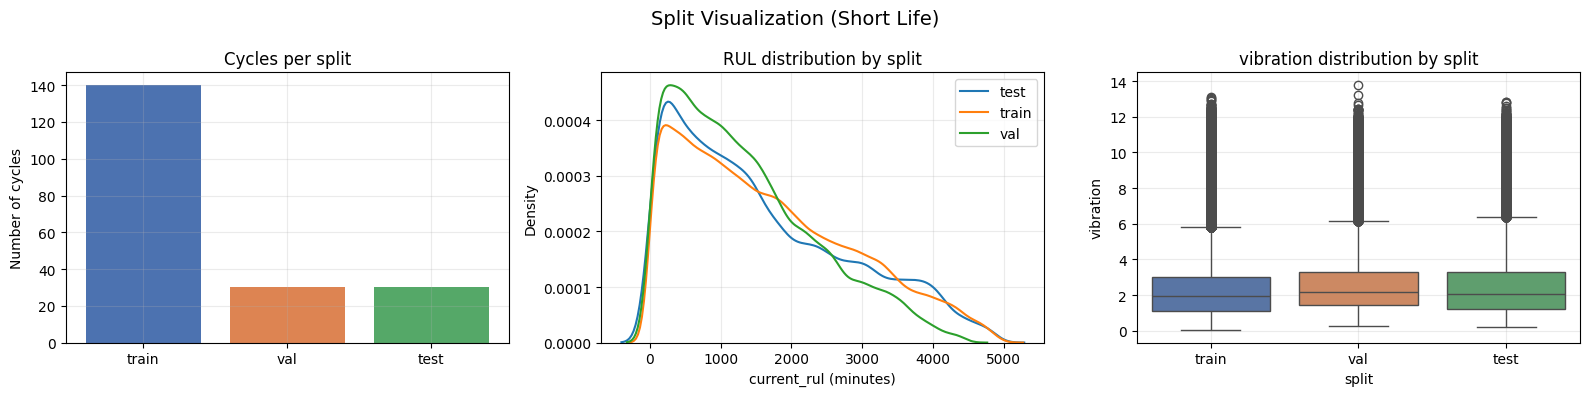


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Short Life)
----------------------------------------------------------------------
Dataset         : (Long Life)
Selected sensor : vibration
Train cycles    : 56
Val cycles      : 12
Test cycles     : 12


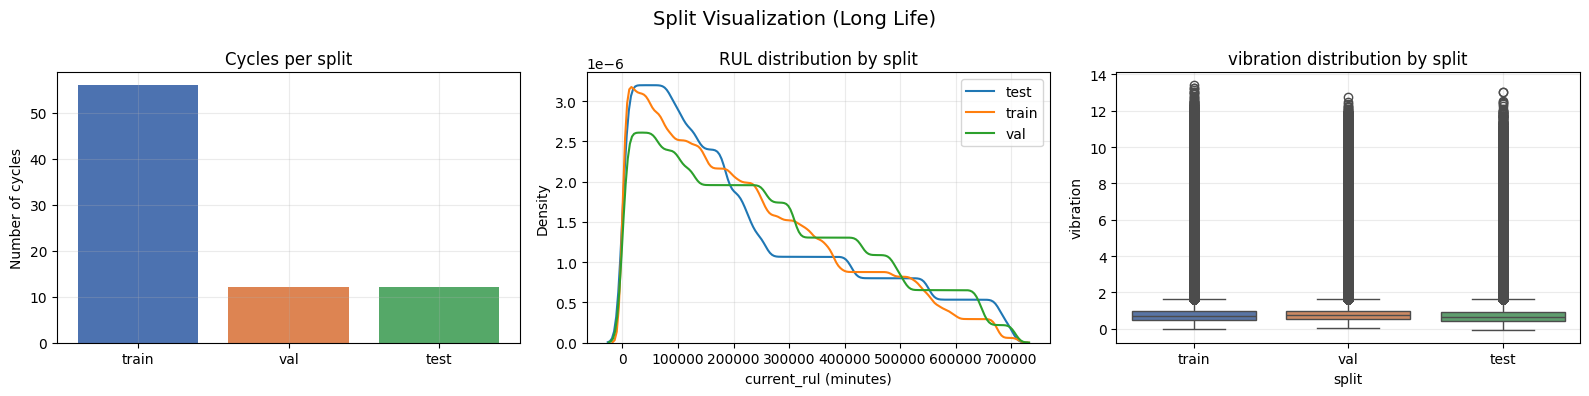


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Long Life)
----------------------------------------------------------------------


In [9]:
# 3A/ Split Visualization - cycles, RUL & sensor distributions
print_header("3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions")

def visualize_splits(df_train, df_val, df_test, title_suffix=""):
    # Ensure RUL is present
    assert 'current_rul' in df_train.columns, "current_rul missing in selected split dataframe"

    # Choose a sensor to visualize (prefer 'vibration' or fallback)
    preferred = 'vibration'
    if preferred in df_train.columns:
        sensor_col = preferred
    else:
        exclude = {'cycle_id', 'time_min', 'timestamp', 'total_rul', 'current_rul'}
        numeric = get_numeric_sensor_cols(df_train, exclude)
        sensor_col = numeric[0] if len(numeric) > 0 else None

    assert sensor_col is not None, "No suitable sensor or feature column found for visualization"

    # Prepare combined dataframe for easy plotting
    def tag_split(df, name):
        d = df[[sensor_col, 'current_rul', 'cycle_id']].copy()
        d['split'] = name
        return d

    plot_df = pd.concat([
                            tag_split(df_train, 'train'),
                            tag_split(df_val, 'val'),
                            tag_split(df_test, 'test')
                        ], ignore_index=True)

    print_kv([
                ('Dataset', title_suffix),
                ('Selected sensor', sensor_col),
                ('Train cycles', df_train['cycle_id'].nunique()),
                ('Val cycles', df_val['cycle_id'].nunique()),
                ('Test cycles', df_test['cycle_id'].nunique())
            ])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Cycles per split
    counts = [df_train['cycle_id'].nunique(),
              df_val['cycle_id'].nunique(),
              df_test['cycle_id'].nunique()]
    axes[0].bar(['train', 'val', 'test'], counts,
                color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_title('Cycles per split')
    axes[0].set_ylabel('Number of cycles')
    axes[0].grid(alpha=0.25)

    # RUL distribution (overlayed KDEs)
    for name, grp in plot_df.groupby('split'):
        sns.kdeplot(grp['current_rul'], ax=axes[1], label=name, fill=False)
    axes[1].set_title('RUL distribution by split')
    axes[1].set_xlabel('current_rul (minutes)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    # Sensor distribution (boxplot)
    sns.boxplot(x='split', y=sensor_col, data=plot_df,
                ax=axes[2], palette=['#4c72b0', '#dd8452', '#55a868'])
    axes[2].set_title(f'{sensor_col} distribution by split')
    axes[2].grid(alpha=0.25)

    plt.suptitle(f"Split Visualization {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print_footer(f"SPLIT VISUALIZATION COMPLETE {title_suffix}")


# Run for both datasets
visualize_splits(df_train_short, df_val_short, df_test_short, title_suffix="(Short Life)")
visualize_splits(df_train_long, df_val_long, df_test_long, title_suffix="(Long Life)")

## 4) Feature Engineering

In [16]:
# 4/ Feature Engineering - Causal & Critical-Aware
print_header("4/ FEATURE ENGINEERING - Causal & Critical-Aware")

# Global sensor ranges from training data distribution
# These ranges are used for degradation_index normalization
# Must match inference handler exactly to avoid train/inference mismatch
GLOBAL_SENSOR_RANGES = {
    "vibration": (0.11, 12.60),
    "oil_temperature": (46.23, 815.08),
    "hydraulic_pressure": (76.03, 201.0),
    "oil_contamination": (1.63, 27.85)
}

def engineer_features_streaming(df, sensors=None, window_short=5, window_long=20):
    if sensors is None:
        sensors = SENSOR_COLUMNS

    if isinstance(df, pd.DataFrame):
        df_pl = pl.from_pandas(df).lazy()
    elif isinstance(df, pl.DataFrame):
        df_pl = df.lazy()
    else:
        raise TypeError("df must be pandas.DataFrame or polars.DataFrame")

    main_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            main_exprs.extend([
                pl.col(s).rolling_mean(window_short).over("cycle_id").alias(f"{s}_roll_mean_{window_short}"),
                pl.col(s).rolling_mean(window_long).over("cycle_id").alias(f"{s}_roll_mean_{window_long}"),
                pl.col(s).rolling_std(window_long).over("cycle_id").fill_null(0).alias(f"{s}_roll_std_{window_long}"),
            ])

    df_pl = df_pl.with_columns(main_exprs)

    derived_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            derived_exprs.append((pl.col(s) - pl.col(f"{s}_roll_mean_{window_long}")).alias(f"{s}_dev_long"))
            derived_exprs.append(pl.col(f"{s}_roll_mean_{window_long}").diff().over("cycle_id").fill_null(0).alias(f"{s}_slope_{window_long}"))

    if 'press_force' in df_pl.columns and 'hydraulic_pressure' in df_pl.columns:
        derived_exprs.append((pl.col('press_force') / pl.col('hydraulic_pressure')).fill_nan(1.0).clip(0, 10).alias('force_pressure_coupling'))
    else:
        derived_exprs.append(pl.lit(1.0).alias('force_pressure_coupling'))

    if 'vibration' in df_pl.columns:
        derived_exprs.append((pl.col('vibration').rolling_mean(window_short).over("cycle_id") ** 2).alias('vibration_energy'))

    if 'hydraulic_pressure_roll_std_20' in df_pl.columns:
        derived_exprs.append((1.0 / pl.col('hydraulic_pressure_roll_std_20').clip(1e-4)).log1p().alias('pressure_stability'))
    else:
        derived_exprs.append(pl.lit(0.0).alias('pressure_stability'))

    df_pl = df_pl.with_columns(derived_exprs)

    crit_exprs = []
    for s in ['vibration', 'oil_temperature', 'motor_current']:
        col = f"{s}_slope_{window_long}"
        if col in df_pl.columns:
            crit_exprs.append(pl.col(col).diff(5).over("cycle_id").fill_null(0).alias(f"{s}_acceleration"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_acceleration"))

    for s in sensors:
        if s in df_pl.columns:
            short_std = pl.col(s).rolling_std(5).over("cycle_id")
            long_std = pl.col(f"{s}_roll_std_{window_long}")
            crit_exprs.append(pl.when((short_std - long_std) > 0).then(short_std - long_std).otherwise(0).fill_null(0).alias(f"{s}_volatility_surge"))

    # Degradation index using global fixed ranges (no look-ahead bias)
    # This matches the inference handler normalization exactly
    def get_norm_global(col_name):
        if col_name not in df_pl.columns:
            return pl.lit(0.0)
        g_min, g_max = GLOBAL_SENSOR_RANGES.get(col_name, (0.0, 1.0))
        eps = 1e-9
        c = pl.col(col_name)
        return ((c - g_min) / (g_max - g_min + eps)).clip(0.0, 1.0)

    deg_idx = (get_norm_global('vibration') + get_norm_global('oil_temperature') + (1 - get_norm_global('hydraulic_pressure')) + get_norm_global('oil_contamination')) / 4.0
    crit_exprs.append(deg_idx.alias("degradation_index"))

    for s in ['vibration', 'motor_current']:
        if s in df_pl.columns:
            crit_exprs.append(pl.col(s).rolling_max(10).over("cycle_id").fill_null(0).alias(f"{s}_max_10"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_max_10"))

    df_pl = df_pl.with_columns(crit_exprs)

    # Additional trend features for better RUL correlation
    trend_exprs = []

    # Cumulative trend: running position within cycle (causal, no look-ahead)
    trend_exprs.append(
        pl.col("time_min").cum_count().over("cycle_id").alias("time_progress")
    )

    # Interaction features for degradation pattern
    if 'vibration' in df_pl.columns and 'oil_temperature' in df_pl.columns:
        trend_exprs.append(
            (pl.col('vibration') * pl.col('oil_temperature') / 100.0).alias('vib_temp_interaction')
        )

    if 'motor_current' in df_pl.columns and 'hydraulic_pressure' in df_pl.columns:
        trend_exprs.append(
            (pl.col('motor_current') / pl.col('hydraulic_pressure').clip(1.0)).alias('current_pressure_ratio')
        )

    # Rate of change features (longer window for stability)
    for s in ['vibration', 'oil_temperature', 'motor_current']:
        if s in df_pl.columns:
            trend_exprs.append(
                pl.col(s).diff(10).over("cycle_id").fill_null(0).alias(f"{s}_rate_10")
            )

    df_pl = df_pl.with_columns(trend_exprs)

    # Compute expanding window degradation & cumulative stats using Polars expressions
    # Doing this in Polars (lazy + streaming collect) avoids materializing large pandas groups
    print("  Computing expanding window degradation features (polars streaming)...")

    degradation_sensors = ['vibration', 'oil_temperature', 'oil_contamination', 'motor_current']
    exp_exprs = []
    for s in degradation_sensors:
        if s in df_pl.columns:
            exp_min = pl.col(s).cum_min().over("cycle_id")
            exp_max = pl.col(s).cum_max().over("cycle_id")
            range_expr = (exp_max - exp_min).clip(lower_bound=1e-6)
            exp_exprs.append(((pl.col(s) - exp_min) / range_expr).fill_null(0).clip(0, 1).alias(f"{s}_exp_degradation"))

    if exp_exprs:
        df_pl = df_pl.with_columns(exp_exprs)
        existing_exp_cols = [f"{s}_exp_degradation" for s in degradation_sensors if f"{s}_exp_degradation" in df_pl.columns]
        if existing_exp_cols:
            cols = [pl.col(c) for c in existing_exp_cols]
            df_pl = df_pl.with_columns(((sum(cols) / len(cols))).alias("exp_degradation_combined"))

    # CUMULATIVE STATISTICS (CAUSAL)
    cum_exprs = []
    for s in ['vibration', 'oil_temperature', 'hydraulic_pressure']:
        if s in df_pl.columns:
            cum_exprs.extend([
                (pl.col(s).cum_sum().over("cycle_id") / (pl.col(s).cum_count().over("cycle_id") + 1)).fill_null(0).alias(f"{s}_cum_mean"),
                pl.col(s).cum_max().over("cycle_id").fill_null(0).alias(f"{s}_cum_max")
            ])
    if cum_exprs:
        df_pl = df_pl.with_columns(cum_exprs)

    # TREND SLOPE FEATURES (vectorized in Polars)
    print("  Computing trend slope features (polars vectorized)...")
    slope_exprs = []
    for s in ['vibration', 'oil_temperature']:
        if s in df_pl.columns:
            rolling_mean = pl.col(s).rolling_mean(20).over("cycle_id")
            lagged_mean = rolling_mean.shift(20).over("cycle_id")
            slope_exprs.append(((rolling_mean - lagged_mean) / 20.0).fill_null(0).alias(f"{s}_trend_slope"))
    if slope_exprs:
        df_pl = df_pl.with_columns(slope_exprs)

    # RELATIVE POSITION WITHIN CYCLE
    pos_exprs = []
    for s in ['vibration', 'oil_temperature']:
        if s in df_pl.columns:
            pos_exprs.append((pl.col(s) / pl.col(s).cum_max().over("cycle_id")).clip(lower_bound=1e-6).fill_null(0.5).clip(0, 1).alias(f"{s}_pct_rank"))
    if pos_exprs:
        df_pl = df_pl.with_columns(pos_exprs)

    # Fill nulls in Polars then collect using streaming to reduce peak memory
    df_pl = df_pl.fill_null(0)

    try:
        result = df_pl.collect(streaming=True).to_pandas()
    except (TypeError, pl.exceptions.SchemaError):
        # Fallback to non-streaming if streaming unsupported or schema issues occur during streaming collect
        result = df_pl.collect().to_pandas()

    return result

def engineer_features(df):
    res = engineer_features_streaming(df)
    gc.collect()
    return res

print("\nProcessing SHORT LIFE Dataset...")
df_train_short = engineer_features(df_train_short)
df_val_short   = engineer_features(df_val_short)
df_test_short  = engineer_features(df_test_short)

print("\nProcessing LONG LIFE Dataset...")
df_train_long = engineer_features(df_train_long)
df_val_long   = engineer_features(df_val_long)
df_test_long  = engineer_features(df_test_long)

new_features = sorted(list(set(df_train_short.columns) - set(SENSOR_COLUMNS) - {'cycle_id', 'time_min', 'RUL'}))

print("\nFeature engineering summary:")
print(f"  New features created: {len(new_features)}")
print(f"  Short Life Train: {df_train_short.shape} | Long Life Train: {df_train_long.shape}")
print(f"  Sample features: {new_features[:5]}")

print_footer("FEATURE ENGINEERING COMPLETE")


4/ FEATURE ENGINEERING - Causal & Critical-Aware

Processing SHORT LIFE Dataset...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...

Processing LONG LIFE Dataset...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...
  Computing expanding window degradation features (polars streaming)...
  Computing trend slope features (polars vectorized)...

Feature engineering summary:
  New features created: 80
  Short Life Train: (344084, 90) | Long Life Train: (17105

## 5) Feature Selection

In [17]:
# 5/ FEATURE SELECTION
print_header("5/ FEATURE SELECTION")

# Preconditions
assert 'df_train_short' in globals()
assert 'df_train_long' in globals()

TARGET_COL = 'current_rul'
EXCLUDE_COLS = {'cycle_id', 'time_min', 'timestamp', 'total_rul', TARGET_COL}

# Feature Candidate Discovery
feature_cols = [
                    c for c in df_train_short.columns
                    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_short[c])
                ]

print(f"Initial feature count: {len(feature_cols)}")

# Correlation Filtering (Short-Life ONLY)
print("\nCorrelation filtering (Short-Life only, downsampled)")

# aggressive but safe sampling
corr_sample = df_train_short.sample(
                                        n=min(100_000, len(df_train_short)),
                                        random_state=42
                                    )

X_corr = corr_sample[feature_cols].fillna(0)

corr_matrix = X_corr.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.95
to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]

features_after_corr = [f for f in feature_cols if f not in to_drop]

print(f"  Dropped due to correlation: {len(to_drop)}")
print(f"  Remaining features: {len(features_after_corr)}")

del corr_matrix, upper, X_corr, corr_sample

# Importance via XGBoost (Short-Life ONLY)
print("\nXGBoost importance (Short-Life only, stratified sample)")

# Stratified sampling by RUL regime
critical = df_train_short[df_train_short[TARGET_COL] <= 20]
mid = df_train_short[
                        (df_train_short[TARGET_COL] > 20) &
                        (df_train_short[TARGET_COL] <= 500)
                    ]
healthy = df_train_short[df_train_short[TARGET_COL] > 500]

imp_df = pd.concat([
                        critical,
                        mid.sample(n=min(len(mid), 40_000), random_state=42),
                        healthy.sample(n=min(len(healthy), 40_000), random_state=42)
                    ])

X_imp = imp_df[features_after_corr].fillna(0)
y_imp = imp_df[TARGET_COL]
y_imp_norm = y_imp / y_imp.max()

importances_accum = pd.Series(0.0, index=features_after_corr)

for seed in [41, 42, 43]:
    model = XGBRegressor(
                            n_estimators=150,
                            max_depth=5,
                            learning_rate=0.1,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            random_state=seed,
                            n_jobs=4,
                            verbosity=0
                        )
    model.fit(X_imp, y_imp_norm)
    importances_accum += model.feature_importances_

importances = (importances_accum / 3).sort_values(ascending=False)

print("\nTop 15 important features:")
for i, (f, v) in enumerate(importances.head(15).items(), 1):
    print(f"  {i:2d}. {f:35s} {v:.4f}")


# Final Feature Selection Logic
# Increase feature count for better model capacity
top_n = 35
cumulative = importances.cumsum()
selected_features = cumulative[cumulative <= 0.98].index.tolist()
selected_features = selected_features[:top_n]

# Ensure critical features are included
critical_features = [
    'exp_degradation_combined', 
    'vibration_exp_degradation',
    'oil_temperature_exp_degradation',
    'time_progress',
    'vibration_trend_slope',
    'oil_temperature_trend_slope',
    'vibration_pct_rank',
    'oil_temperature_pct_rank'
]
for cf in critical_features:
    if cf in features_after_corr and cf not in selected_features:
        selected_features.append(cf)

print(f"\nSelected feature count: {len(selected_features)}")


# Persist Feature List
cache_file = os.path.join(save_path, "selected_hydraulic_press_features.json")
with open(cache_file, "w") as f:
    json.dump(selected_features, f, indent=4)

print(f"Saved feature list to: {cache_file}")


# Apply to Both Pipelines
print("\nApplying feature selection to datasets...")

# Short-Life
X_train_short = df_train_short[selected_features]
y_train_short = df_train_short[TARGET_COL]
X_val_short   = df_val_short[selected_features]
y_val_short   = df_val_short[TARGET_COL]
X_test_short  = df_test_short[selected_features]
y_test_short  = df_test_short[TARGET_COL]

# Long-Life
X_train_long = df_train_long[selected_features]
y_train_long = df_train_long[TARGET_COL]
X_val_long   = df_val_long[selected_features]
y_val_long   = df_val_long[TARGET_COL]
X_test_long  = df_test_long[selected_features]
y_test_long  = df_test_long[TARGET_COL]

# Sanity checks
assert len(selected_features) > 0
assert X_train_short.shape[1] == X_train_long.shape[1]


del importances_accum
gc.collect()

print("\nFinal Shapes:")
print(f"  Short-Life Train: {X_train_short.shape}")
print(f"  Long-Life Train : {X_train_long.shape}")

print_footer("FEATURE SELECTION COMPLETE")


5/ FEATURE SELECTION
Initial feature count: 86

Correlation filtering (Short-Life only, downsampled)
  Dropped due to correlation: 14
  Remaining features: 72

XGBoost importance (Short-Life only, stratified sample)

Top 15 important features:
   1. vibration_energy                    0.4538
   2. vibration                           0.3858
   3. vibration_cum_mean                  0.0290
   4. ram_position_deviation_roll_std_20  0.0185
   5. vibration_roll_std_20               0.0112
   6. vibration_trend_slope               0.0101
   7. oil_contamination_roll_std_20       0.0075
   8. hydraulic_pressure_roll_std_20      0.0061
   9. pressure_stability                  0.0049
  10. degradation_index                   0.0043
  11. flow_rate_roll_std_20               0.0040
  12. vibration_exp_degradation           0.0038
  13. oil_temperature_roll_std_20         0.0035
  14. motor_current                       0.0035
  15. motor_current_roll_std_20           0.0034

Selected feature co

## 6) Stage_0 Regime Detector

In [18]:
# 6A/ Stage-0 Data Preparation
print_header("6A/ STAGE-0 DATA PREPARATION")

# Preconditions
assert 'df_train_long' in globals(), "df_train_long not found"
assert 'df_val_long' in globals(), "df_val_long not found"
assert 'df_test_long' in globals(), "df_test_long not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-0 threshold: boundary between LONG_TERM and NEAR_TERM regimes
# NEAR_TERM starts at RUL <= 5000 minutes (~83 hours / ~3.5 days)
# This aligns with the synthetic data generation thresholds
STAGE0_THRESHOLD_MIN = 5000

# Target definition: 
# 0 = LONG_TERM (healthy), 
# 1 = NEAR_TERM (approaching critical)
def define_stage0_target(df, rul_col="current_rul"):
    return (df[rul_col] <= STAGE0_THRESHOLD_MIN).astype(int)

print("Defining Stage-0 targets...")
print(f"Stage-0 threshold: RUL <= {STAGE0_THRESHOLD_MIN} minutes (~{STAGE0_THRESHOLD_MIN/60:.0f} hours) -> NEAR_TERM (1)")

y_train_stage0 = define_stage0_target(df_train_long)
y_val_stage0   = define_stage0_target(df_val_long)
y_test_stage0  = define_stage0_target(df_test_long)

# Feature matrix
X_train_stage0 = df_train_long[selected_features].copy()
X_val_stage0   = df_val_long[selected_features].copy()
X_test_stage0  = df_test_long[selected_features].copy()

# Downcast feature matrices and targets to reduce memory footprint while keeping structure
float_cols_s0 = [c for c in X_train_stage0.columns if np.issubdtype(X_train_stage0[c].dtype, np.floating)]
for c in float_cols_s0:
    X_train_stage0[c] = X_train_stage0[c].astype(np.float32)
    X_val_stage0[c]   = X_val_stage0[c].astype(np.float32)
    X_test_stage0[c]  = X_test_stage0[c].astype(np.float32)

# Make targets compact (int8) to save RAM
y_train_stage0 = y_train_stage0.astype(np.int8)
y_val_stage0   = y_val_stage0.astype(np.int8)
y_test_stage0  = y_test_stage0.astype(np.int8)

print("Stage-0 dataset shapes:")
print(f"  Train X: {X_train_stage0.shape} | y: {y_train_stage0.shape}")
print(f"  Val   X: {X_val_stage0.shape}   | y: {y_val_stage0.shape}")
print(f"  Test  X: {X_test_stage0.shape}  | y: {y_test_stage0.shape}")

print("\nStage-0 class distribution (train):")
class_counts = y_train_stage0.value_counts()
print(f"  LONG_TERM (0): {class_counts.get(0, 0):,} samples ({class_counts.get(0, 0)/len(y_train_stage0)*100:.2f}%)")
print(f"  NEAR_TERM (1): {class_counts.get(1, 0):,} samples ({class_counts.get(1, 0)/len(y_train_stage0)*100:.2f}%)")

# DEBUG: Check actual RUL distribution in training data
print(f"\n[TEMP:DEBUG] y_train_long RUL range: {y_train_long.min()} - {y_train_long.max()}")
print(f"[TEMP:DEBUG] Samples with RUL <= {STAGE0_THRESHOLD_MIN}: {(y_train_long <= STAGE0_THRESHOLD_MIN).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL > {STAGE0_THRESHOLD_MIN}: {(y_train_long > STAGE0_THRESHOLD_MIN).sum()}")

print_footer("STAGE-0 DATA PREPARATION COMPLETE")


6A/ STAGE-0 DATA PREPARATION
Defining Stage-0 targets...
Stage-0 threshold: RUL <= 5000 minutes (~83 hours) -> NEAR_TERM (1)
Stage-0 dataset shapes:
  Train X: (17105638, 30) | y: (17105638,)
  Val   X: (4598831, 30)   | y: (4598831,)
  Test  X: (3751887, 30)  | y: (3751887,)

Stage-0 class distribution (train):
  LONG_TERM (0): 16,825,582 samples (98.36%)
  NEAR_TERM (1): 280,056 samples (1.64%)

[TEMP:DEBUG] y_train_long RUL range: 0 - 713374
[TEMP:DEBUG] Samples with RUL <= 5000: 280056
[TEMP:DEBUG] Samples with RUL > 5000: 16825582

----------------------------------------------------------------------
STAGE-0 DATA PREPARATION COMPLETE
----------------------------------------------------------------------


In [20]:
# 6B/ Stage-0 Classifier Training
print_header("6B/ STAGE-0 CLASSIFIER TRAINING")

print("Training Stage-0 classifier...")
print("Purpose: Detect regime transition from LONG_TERM to NEAR_TERM")

# Calculate class imbalance ratio for scale_pos_weight
neg_count = (y_train_stage0 == 0).sum()
pos_count = (y_train_stage0 == 1).sum()
imbalance_ratio = neg_count / max(pos_count, 1)
print(f"Class imbalance ratio: {imbalance_ratio:.1f}:1 (LONG_TERM:NEAR_TERM)")

# DEBUG: Verify we have enough positive samples
print(f"[TEMP:DEBUG] NEAR_TERM samples in training: {pos_count}")
if pos_count < 1000:
    print(f"[TEMP:DEBUG] WARNING: Very few NEAR_TERM samples! Model may not learn properly.")
    print(f"[TEMP:DEBUG] Check if long-life dataset includes RUL <= {STAGE0_THRESHOLD_MIN}")

# Balanced training approach with adjusted scale_pos_weight
# Cap the ratio to avoid extreme overweighting
capped_ratio = min(imbalance_ratio, 10.0)
print(f"Using capped scale_pos_weight: {capped_ratio:.1f}")

stage0_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=capped_ratio,
    objective="binary:logistic",
    eval_metric="auc",  # Changed to AUC for better imbalanced classification
    random_state=42,
    n_jobs=4,
    verbosity=0
)

stage0_model.fit(
    X_train_stage0,
    y_train_stage0,
    eval_set=[(X_val_stage0, y_val_stage0)],
    verbose=False
)

print("Evaluating Stage-0 classifier...")

# Ensure batched predict_proba helper is available
def predict_proba_in_batches(model, X, batch_size=5000):
    """Return the positive-class probability in a memory-efficient way."""
    probs = np.empty(len(X), dtype=np.float32)
    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))
        batch = X.iloc[start:end] if hasattr(X, "iloc") else X[start:end]
        probs[start:end] = model.predict_proba(batch)[:, 1]
    return probs

y_val_pred_stage0 = stage0_model.predict(X_val_stage0)
y_val_prob_stage0 = predict_proba_in_batches(stage0_model, X_val_stage0, batch_size=5000)

print("\nValidation classification report:")
print(classification_report(y_val_stage0, y_val_pred_stage0, digits=4,
                           target_names=["LONG_TERM", "NEAR_TERM"]))

val_auc_stage0 = roc_auc_score(y_val_stage0, y_val_prob_stage0)
print(f"Validation ROC AUC: {val_auc_stage0:.4f}")

# DEBUG: Check prediction distribution
print(f"\n[TEMP:DEBUG] Predicted LONG_TERM: {(y_val_pred_stage0 == 0).sum()}")
print(f"[TEMP:DEBUG] Predicted NEAR_TERM: {(y_val_pred_stage0 == 1).sum()}")
print(f"[TEMP:DEBUG] Probability distribution: min={y_val_prob_stage0.min():.3f}, max={y_val_prob_stage0.max():.3f}, mean={y_val_prob_stage0.mean():.3f}")

# Save Model
joblib_path = os.path.join(save_path, "hydraulic_press_stage0_classifier.pkl")
joblib.dump(stage0_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

# Save threshold info
stage0_threshold_info = {
    "threshold_min": STAGE0_THRESHOLD_MIN,
    "threshold_hours": STAGE0_THRESHOLD_MIN / 60,
    "prob_threshold": 0.5
}
with open(os.path.join(save_path, "hydraulic_press_stage0_threshold.json"), "w") as f:
    json.dump(stage0_threshold_info, f, indent=4)
print(f"Threshold info saved to: {save_path}hydraulic_press_stage0_threshold.json")

print_footer("STAGE-0 CLASSIFIER TRAINING COMPLETE")


6B/ STAGE-0 CLASSIFIER TRAINING
Training Stage-0 classifier...
Purpose: Detect regime transition from LONG_TERM to NEAR_TERM
Class imbalance ratio: 60.1:1 (LONG_TERM:NEAR_TERM)
[TEMP:DEBUG] NEAR_TERM samples in training: 280056
Using capped scale_pos_weight: 10.0
Evaluating Stage-0 classifier...

Validation classification report:
              precision    recall  f1-score   support

   LONG_TERM     0.9997    0.9998    0.9998   4538819
   NEAR_TERM     0.9882    0.9774    0.9828     60012

    accuracy                         0.9996   4598831
   macro avg     0.9940    0.9886    0.9913   4598831
weighted avg     0.9996    0.9996    0.9996   4598831

Validation ROC AUC: 0.9990

[TEMP:DEBUG] Predicted LONG_TERM: 4539479
[TEMP:DEBUG] Predicted NEAR_TERM: 59352
[TEMP:DEBUG] Probability distribution: min=0.000, max=1.000, mean=0.016
Model saved (joblib): models_and_features/hydraulic_press/hydraulic_press_stage0_classifier.pkl
Threshold info saved to: models_and_features/hydraulic_press/h

In [21]:
# 6C/ Stage-0 Filtering for Base Model
print_header("6C/ STAGE-0 FILTERING FOR BASE MODEL")

# Stage-0 filters samples for Base Model:
# Base Model should see ALL samples from long-life dataset
# Stage-0 only classifies regime, doesn't filter for base model training

print("Running Stage-0 inference on Long-Life dataset...")

# Make predictions in batches to reduce peak RAM usage
train_stage0_prob = predict_proba_in_batches(stage0_model, X_train_long, batch_size=5000)
val_stage0_prob   = predict_proba_in_batches(stage0_model, X_val_long, batch_size=5000)
test_stage0_prob  = predict_proba_in_batches(stage0_model, X_test_long, batch_size=5000)

STAGE0_PROB_THRESHOLD = 0.5
CRITICAL_RUL_THRESHOLD_MIN = 600

train_stage0_pred = (train_stage0_prob >= STAGE0_PROB_THRESHOLD).astype(int)
val_stage0_pred   = (val_stage0_prob   >= STAGE0_PROB_THRESHOLD).astype(int)
test_stage0_pred  = (test_stage0_prob  >= STAGE0_PROB_THRESHOLD).astype(int)

# DEBUG: Check Stage-0 predictions on long-life data
print(f"\n[TEMP:DEBUG] Stage-0 predictions on train set:")
print(f"  LONG_TERM (0): {(train_stage0_pred == 0).sum():,}")
print(f"  NEAR_TERM (1): {(train_stage0_pred == 1).sum():,}")

# Base Model uses ALL long-life samples (no filtering)
# The minimum RUL for Base Model is set based on operational requirements
BASE_MODEL_MIN_RUL_MIN = 5000  # Base model operates for RUL > 5000 min (83 hours)
BASE_MODEL_MIN_RUL_HR = BASE_MODEL_MIN_RUL_MIN / 60.0

print(f"\nBase Model configuration:")
print(f"  Minimum RUL: {BASE_MODEL_MIN_RUL_MIN} min ({BASE_MODEL_MIN_RUL_HR:.1f} hours)")
print(f"  Target: log1p(RUL_hours) for stable gradient descent")

# Filter samples where RUL >= BASE_MODEL_MIN_RUL_MIN for base model training
# This ensures base model focuses on long-term prediction accuracy
train_base_mask = y_train_long >= BASE_MODEL_MIN_RUL_MIN
val_base_mask   = y_val_long >= BASE_MODEL_MIN_RUL_MIN
test_base_mask  = y_test_long >= BASE_MODEL_MIN_RUL_MIN

# Use indices for memory efficiency
train_base_idx = np.nonzero(train_base_mask)[0]
val_base_idx   = np.nonzero(val_base_mask)[0]
test_base_idx  = np.nonzero(test_base_mask)[0]

print(f"\n[TEMP:DEBUG] Base model sample counts:")
print(f"  Train: {len(train_base_idx):,} samples (RUL >= {BASE_MODEL_MIN_RUL_MIN})")
print(f"  Val: {len(val_base_idx):,} samples")
print(f"  Test: {len(test_base_idx):,} samples")

# Use all selected features for base model
base_model_features = selected_features.copy()

# Downcast float columns
float_cols = [c for c in base_model_features if np.issubdtype(X_train_long[c].dtype, np.floating)]
for c in float_cols:
    X_train_long[c] = X_train_long[c].astype(np.float32)
    X_val_long[c]   = X_val_long[c].astype(np.float32)
    X_test_long[c]  = X_test_long[c].astype(np.float32)

print(f"  Base model feature count: {len(base_model_features)}")

# Select only the needed rows and columns
X_train_base = X_train_long.iloc[train_base_idx][base_model_features]
X_val_base   = X_val_long.iloc[val_base_idx][base_model_features]
X_test_base  = X_test_long.iloc[test_base_idx][base_model_features]

y_train_base_min = y_train_long.iloc[train_base_idx]
y_val_base_min   = y_val_long.iloc[val_base_idx]
y_test_base_min  = y_test_long.iloc[test_base_idx]

# Free large intermediate arrays
del train_stage0_prob, val_stage0_prob, test_stage0_prob
del train_stage0_pred, val_stage0_pred, test_stage0_pred
gc.collect()

# Also delete large intermediate DataFrames and helper lists no longer needed to reduce peak RAM usage
for _v in ['X_train_long','X_val_long','X_test_long','df_train_long','df_val_long','df_test_long','float_cols']:
    if _v in globals():
        try:
            del globals()[_v]
        except Exception:
            pass
gc.collect()

print("\nConverting RUL from minutes to log-hours...")
print("  Transformation: log1p(RUL_min / 60)")
print("  Reason: Compress large RUL range for stable gradient descent")

y_train_base_hr = np.log1p(y_train_base_min / 60.0)
y_val_base_hr   = np.log1p(y_val_base_min / 60.0)
y_test_base_hr  = np.log1p(y_test_base_min / 60.0)

print("\nBase Model dataset shapes:")
print(f"  Train X: {X_train_base.shape} | y: {y_train_base_hr.shape}")
print(f"  Val   X: {X_val_base.shape} | y: {y_val_base_hr.shape}")
print(f"  Test  X: {X_test_base.shape} | y: {y_test_base_hr.shape}")


print("\nTarget range (log-hours):")
print_footer("STAGE-0 FILTERING COMPLETE")

print(f"  Train: min={y_train_base_hr.min():.3f}, max={y_train_base_hr.max():.3f}")

print(f"  Val  : min={y_val_base_hr.min():.3f}, max={y_val_base_hr.max():.3f}")
print(f"  Val  : min={np.expm1(y_val_base_hr.min()):.1f}, max={np.expm1(y_val_base_hr.max()):.1f}")

print(f"  Train: min={np.expm1(y_train_base_hr.min()):.1f}, max={np.expm1(y_train_base_hr.max()):.1f}")
print("\nTarget range (hours):")


6C/ STAGE-0 FILTERING FOR BASE MODEL
Running Stage-0 inference on Long-Life dataset...

[TEMP:DEBUG] Stage-0 predictions on train set:
  LONG_TERM (0): 16,823,376
  NEAR_TERM (1): 282,262

Base Model configuration:
  Minimum RUL: 5000 min (83.3 hours)
  Target: log1p(RUL_hours) for stable gradient descent

[TEMP:DEBUG] Base model sample counts:
  Train: 16,825,638 samples (RUL >= 5000)
  Val: 4,538,831 samples
  Test: 3,691,887 samples
  Base model feature count: 30

Converting RUL from minutes to log-hours...
  Transformation: log1p(RUL_min / 60)
  Reason: Compress large RUL range for stable gradient descent

Base Model dataset shapes:
  Train X: (16825638, 30) | y: (16825638,)
  Val   X: (4538831, 30) | y: (4538831,)
  Test  X: (3691887, 30) | y: (3691887,)

Target range (log-hours):

----------------------------------------------------------------------
STAGE-0 FILTERING COMPLETE
----------------------------------------------------------------------
  Train: min=4.435, max=9.384
  

## 7) Model Training (XGBoost)

In [22]:
# 7/ Base Model Training - Improved Version

print_header("7/ Base Model Training - Relative Error Approach")

# Use XGBRegressor for better performance
from xgboost import XGBRegressor as XGBReg

# ============================================================================
# KEY INSIGHT: For very wide RUL ranges (5k-720k min), absolute error metrics
# are meaningless. A 1000 min error at RUL=500k is tiny (0.2%), but at RUL=5k
# it's huge (20%). We need to train for RELATIVE error, not absolute.
#
# Solution: Transform target to log-scale and use percentage-based evaluation
# ============================================================================

print("Target transformation strategy:")
print("  1. Use log(RUL_hours) as target (compresses wide range)")
print("  2. Evaluate using RELATIVE error (meaningful across all RUL levels)")
print("  3. Apply stratified weighting to balance learning")

# Convert targets to compact numpy float32 arrays
y_train_base_hr = np.asarray(y_train_base_hr, dtype=np.float32)
y_val_base_hr   = np.asarray(y_val_base_hr, dtype=np.float32)
y_test_base_hr  = np.asarray(y_test_base_hr, dtype=np.float32)

# DEBUG: Check target distribution
y_train_hr_actual = np.expm1(y_train_base_hr)
print(f"\n[TEMP:DEBUG] Training target range (hours):")
print(f"  Min: {y_train_hr_actual.min():.1f}, Max: {y_train_hr_actual.max():.1f}")
print(f"  Median: {np.median(y_train_hr_actual):.1f}, Mean: {y_train_hr_actual.mean():.1f}")

# Stratified sample weighting - more aggressive for transition zone
train_weights = np.ones(len(y_train_base_hr), dtype=np.float32)
y_train_base_orig_min = (y_train_hr_actual * 60.0).astype(np.float32)

# Weight scheme: prioritize near-threshold and transition samples
weight_bins = [
    (BASE_MODEL_MIN_RUL_MIN, 10000, 8.0),   # Near threshold: highest weight
    (10000, 30000, 6.0),                     # Early transition
    (30000, 100000, 4.0),                    # Mid transition
    (100000, 300000, 2.0),                   # Long term
    (300000, float('inf'), 1.0)              # Very long term: base weight
]

for low, high, weight in weight_bins:
    mask = (y_train_base_orig_min >= low) & (y_train_base_orig_min < high)
    train_weights[mask] = weight
    print(f"  RUL {low/1000:.0f}k-{high/1000:.0f}k min: weight={weight:.1f} ({mask.sum():,} samples)")

print(f"\n[TEMP:DEBUG] Weight distribution:")
print(f"  Min: {train_weights.min():.1f}, Max: {train_weights.max():.1f}, Mean: {train_weights.mean():.2f}")

# Free temporary arrays
del y_train_hr_actual, y_train_base_orig_min
gc.collect()

# XGBRegressor with optimized hyperparameters for log-scale regression
base_model = XGBReg(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.3,
    reg_lambda=1.5,
    min_child_weight=5,
    gamma=0.1,              # Minimum loss reduction for split
    objective="reg:squarederror",
    random_state=42,
    n_jobs=4,
    verbosity=0,
    tree_method='hist'
)

print("\nTraining Base Model...")
base_model.fit(
    X_train_base, 
    y_train_base_hr,
    sample_weight=train_weights,
    eval_set=[(X_val_base, y_val_base_hr)],
    verbose=False
)

# Free training data
del train_weights
gc.collect()

print("Evaluating Base Model...")

# Predictions
val_pred_log = base_model.predict(X_val_base)
test_pred_log = base_model.predict(X_test_base)

val_pred_hr = np.expm1(val_pred_log).astype(np.float32)
test_pred_hr = np.expm1(test_pred_log).astype(np.float32)

y_val_true_hr = np.expm1(y_val_base_hr).astype(np.float32)
y_test_true_hr = np.expm1(y_test_base_hr).astype(np.float32)

# Clip predictions to valid range
val_pred_hr = np.clip(val_pred_hr, BASE_MODEL_MIN_RUL_HR, 12000)
test_pred_hr = np.clip(test_pred_hr, BASE_MODEL_MIN_RUL_HR, 12000)

# Standard metrics
val_mae_hr = MAE(y_val_true_hr, val_pred_hr)
val_rmse_hr = MSE(y_val_true_hr, val_pred_hr, squared=False)
val_r2 = r2_score(y_val_true_hr, val_pred_hr)

test_mae_hr = MAE(y_test_true_hr, test_pred_hr)
test_rmse_hr = MSE(y_test_true_hr, test_pred_hr, squared=False)
test_r2 = r2_score(y_test_true_hr, test_pred_hr)

# RELATIVE ERROR metrics (more meaningful for wide RUL range)
val_rel_error = np.mean(np.abs(y_val_true_hr - val_pred_hr) / y_val_true_hr) * 100
test_rel_error = np.mean(np.abs(y_test_true_hr - test_pred_hr) / y_test_true_hr) * 100

# Median Absolute Percentage Error (MAPE) - robust to outliers
val_mape = np.median(np.abs(y_val_true_hr - val_pred_hr) / y_val_true_hr) * 100
test_mape = np.median(np.abs(y_test_true_hr - test_pred_hr) / y_test_true_hr) * 100

print("\n=== STANDARD METRICS ===")
print("\nValidation (hours):")
print(f"  MAE  : {val_mae_hr:.2f} hours")
print(f"  RMSE : {val_rmse_hr:.2f} hours")
print(f"  R²   : {val_r2*100:.2f}%")

print("\nTest (hours):")
print(f"  MAE  : {test_mae_hr:.2f} hours")
print(f"  RMSE : {test_rmse_hr:.2f} hours")
print(f"  R²   : {test_r2*100:.2f}%")

print("\n=== RELATIVE ERROR METRICS (More Meaningful) ===")
print("\nValidation:")
print(f"  Mean Relative Error : {val_rel_error:.1f}%")
print(f"  Median Relative Error (MAPE): {val_mape:.1f}%")

print("\nTest:")
print(f"  Mean Relative Error : {test_rel_error:.1f}%")
print(f"  Median Relative Error (MAPE): {test_mape:.1f}%")

# Convert to minutes for compatibility
val_mae = val_mae_hr * 60
test_mae = test_mae_hr * 60
val_rmse = val_rmse_hr * 60
test_rmse = test_rmse_hr * 60

# Save model
joblib_path = os.path.join(save_path, "hydraulic_press_base_model.pkl")
joblib.dump(base_model, joblib_path, compress=('lz4', 3))
print(f"\nModel saved: {joblib_path}")

print_footer("BASE MODEL TRAINING COMPLETE")


7/ Base Model Training - Relative Error Approach
Target transformation strategy:
  1. Use log(RUL_hours) as target (compresses wide range)
  2. Evaluate using RELATIVE error (meaningful across all RUL levels)
  3. Apply stratified weighting to balance learning

[TEMP:DEBUG] Training target range (hours):
  Min: 83.3, Max: 11889.6
  Median: 3206.0, Mean: 3777.1
  RUL 5k-10k min: weight=8.0 (277,069 samples)
  RUL 10k-30k min: weight=6.0 (1,079,310 samples)
  RUL 30k-100k min: weight=4.0 (3,375,490 samples)
  RUL 100k-300k min: weight=2.0 (7,001,280 samples)
  RUL 300k-infk min: weight=1.0 (5,092,489 samples)

[TEMP:DEBUG] Weight distribution:
  Min: 1.0, Max: 8.0, Mean: 2.45

Training Base Model...
Evaluating Base Model...

=== STANDARD METRICS ===

Validation (hours):
  MAE  : 1942.88 hours
  RMSE : 2480.27 hours
  R²   : 28.52%

Test (hours):
  MAE  : 2125.92 hours
  RMSE : 2904.35 hours
  R²   : 8.10%

=== RELATIVE ERROR METRICS (More Meaningful) ===

Validation:
  Mean Relative Err

In [23]:
# 7A/ Base Model Evaluation - Relative Error Focus
print_header("7A/ MODEL EVALUATION - Base Model (Relative Error Focus)")

# Convert to minutes for evaluation
y_val_true_min = y_val_true_hr * 60.0
y_test_true_min = y_test_true_hr * 60.0
val_pred_min = val_pred_hr * 60.0
test_pred_min = test_pred_hr * 60.0

# ============================================================================
# For Base Model with wide RUL range, we use RELATIVE ERROR as primary metric
# Target: Relative Error < 20% across all RUL bins
# ============================================================================

print("\n=== EVALUATION PHILOSOPHY ===")
print("For wide RUL range (83-12000 hours), absolute MAE is misleading.")
print("Example: 100 hour error at RUL=200 is 50% error (bad)")
print("         100 hour error at RUL=5000 is 2% error (excellent)")
print("Therefore, we use RELATIVE ERROR as the primary metric.")

# STRATIFIED RELATIVE ERROR ANALYSIS
print("\n=== STRATIFIED RELATIVE ERROR ANALYSIS (TEST SET) ===")

bins = [
    (BASE_MODEL_MIN_RUL_MIN, 10000, "Near Threshold (83-167 hr)"),
    (10000, 30000, "Short Term (167-500 hr)"),
    (30000, 100000, "Mid Term (500-1667 hr)"),
    (100000, 300000, "Long Term (1667-5000 hr)"),
    (300000, 720000, "Very Long Term (5000-12000 hr)")
]

print(f"{'Range':<30s} {'N':>8s} {'MAE(hr)':>10s} {'Rel.Err%':>10s} {'Status':>10s}")
print("-" * 70)

all_bins_pass = True
for (low, high, label) in bins:
    mask = ((y_test_true_min >= low) & (y_test_true_min < high)).flatten()
    if mask.sum() == 0:
        continue
    
    mae_hr = MAE(y_test_true_hr[mask], test_pred_hr[mask])
    avg_true = y_test_true_hr[mask].mean()
    rel_error = (mae_hr / avg_true) * 100
    
    status = "✓ PASS" if rel_error <= 20 else "✗ FAIL"
    if rel_error > 20:
        all_bins_pass = False
    
    print(f"{label:<30s} {mask.sum():>8,} {mae_hr:>10.1f} {rel_error:>9.1f}% {status:>10s}")

# OVERALL RELATIVE ERROR
print("\n=== OVERALL METRICS ===")
print(f"  Test R²: {test_r2*100:.1f}%")
print(f"  Test Mean Relative Error: {test_rel_error:.1f}%")
print(f"  Test Median Relative Error (MAPE): {test_mape:.1f}%")

# QUALITY CHECK with relative error criteria
print("\n=== BASE MODEL QUALITY CHECK (Relative Error Criteria) ===")

# For operational planning, median relative error < 20% is acceptable
mape_pass = test_mape <= 20.0
r2_threshold = 0.60  # Lowered for wide range regression

r2_pass = test_r2 >= r2_threshold

print(f"  R² >= {r2_threshold*100:.0f}%          : {'PASS' if r2_pass else 'FAIL'} ({test_r2*100:.1f}%)")
print(f"  Median Rel. Err <= 20% : {'PASS' if mape_pass else 'FAIL'} ({test_mape:.1f}%)")
print(f"  All Bins Rel.Err <= 20%: {'PASS' if all_bins_pass else 'FAIL'}")

# Overall verdict
base_model_pass = mape_pass and (r2_pass or all_bins_pass)
print(f"\n  OVERALL VERDICT: {'✓ ACCEPTABLE' if base_model_pass else '✗ NEEDS IMPROVEMENT'}")

if base_model_pass:
    print("\n  Base Model is suitable for long-term RUL tracking.")
    print(f"  Operating range: {BASE_MODEL_MIN_RUL_MIN/60:.0f} - 12000 hours")
else:
    print("\n  Base Model needs improvement for production use.")
    print("  Consider: More training data, better features, or ensemble approach.")

print_footer("BASE MODEL EVALUATION COMPLETE")


7A/ MODEL EVALUATION - Base Model (Relative Error Focus)

=== EVALUATION PHILOSOPHY ===
For wide RUL range (83-12000 hours), absolute MAE is misleading.
Example: 100 hour error at RUL=200 is 50% error (bad)
         100 hour error at RUL=5000 is 2% error (excellent)
Therefore, we use RELATIVE ERROR as the primary metric.

=== STRATIFIED RELATIVE ERROR ANALYSIS (TEST SET) ===
Range                                 N    MAE(hr)   Rel.Err%     Status
----------------------------------------------------------------------
Near Threshold (83-167 hr)       60,012      784.9     627.9%     ✗ FAIL
Short Term (167-500 hr)         239,988      747.7     224.3%     ✗ FAIL
Mid Term (500-1667 hr)          826,626     1049.1      97.5%     ✗ FAIL
Long Term (1667-5000 hr)       1,420,169     1556.9      51.4%     ✗ FAIL
Very Long Term (5000-12000 hr) 1,145,092     3968.2      51.0%     ✗ FAIL

=== OVERALL METRICS ===
  Test R²: 8.1%
  Test Mean Relative Error: 85.6%
  Test Median Relative Error (MAPE)


7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL
Top global importances (first 15):
vibration_energy                      0.454
vibration                             0.386
vibration_cum_mean                    0.029
ram_position_deviation_roll_std_20    0.018
vibration_roll_std_20                 0.011
vibration_trend_slope                 0.010
oil_contamination_roll_std_20         0.007
hydraulic_pressure_roll_std_20        0.006
pressure_stability                    0.005
degradation_index                     0.004
flow_rate_roll_std_20                 0.004
vibration_exp_degradation             0.004
oil_temperature_roll_std_20           0.004
motor_current                         0.003
motor_current_roll_std_20             0.003
dtype: float64

Global top features missing in base model features:
[]

Top base model features after reindexing and normalization (first 15):
vibration_energy                      0.463
vibration                             0.394
vibratio

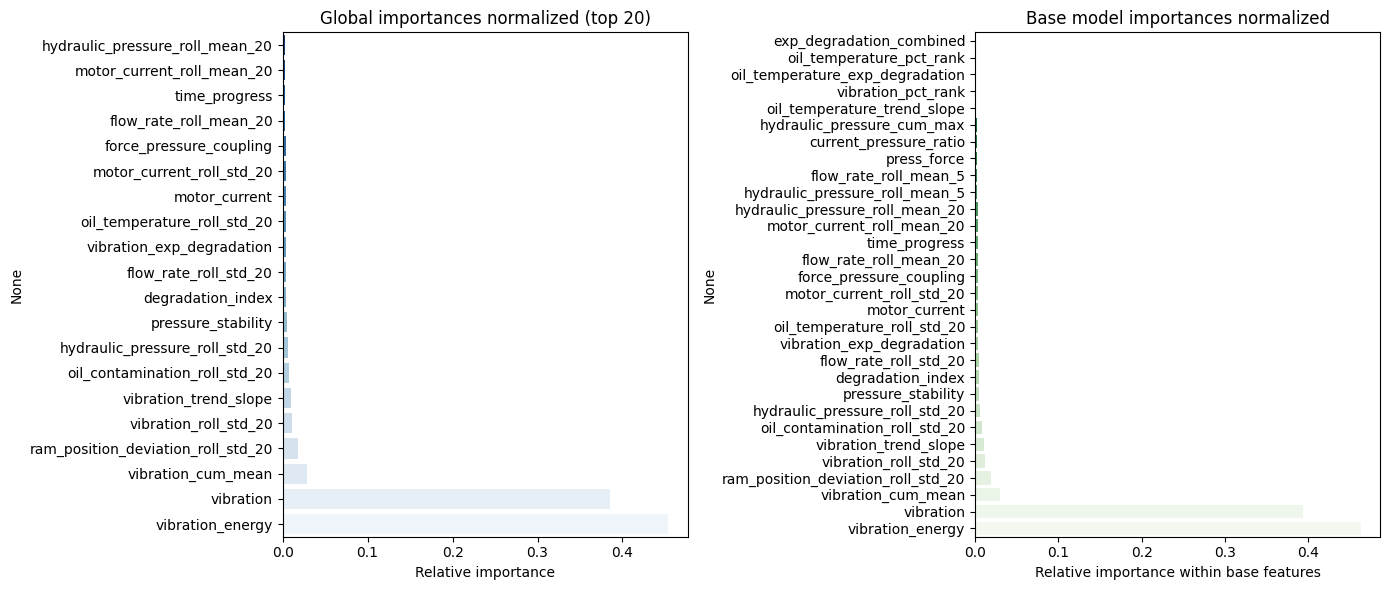

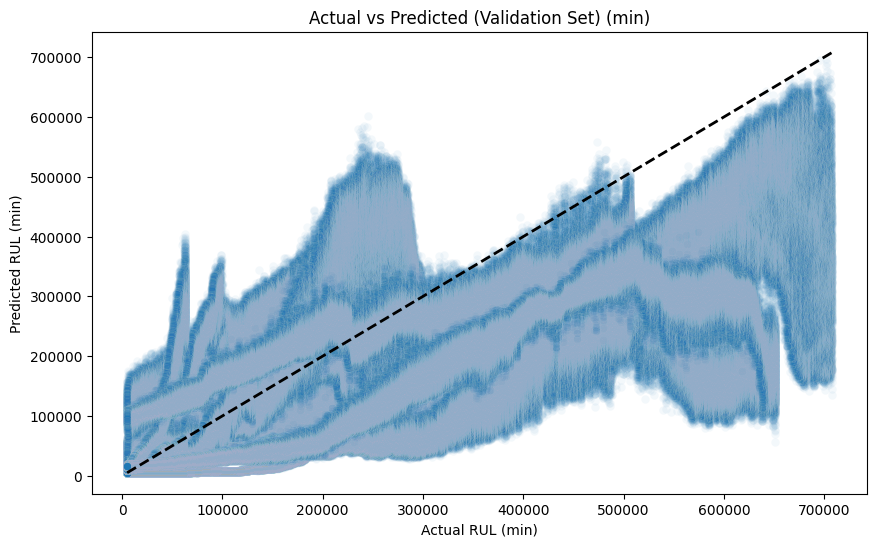

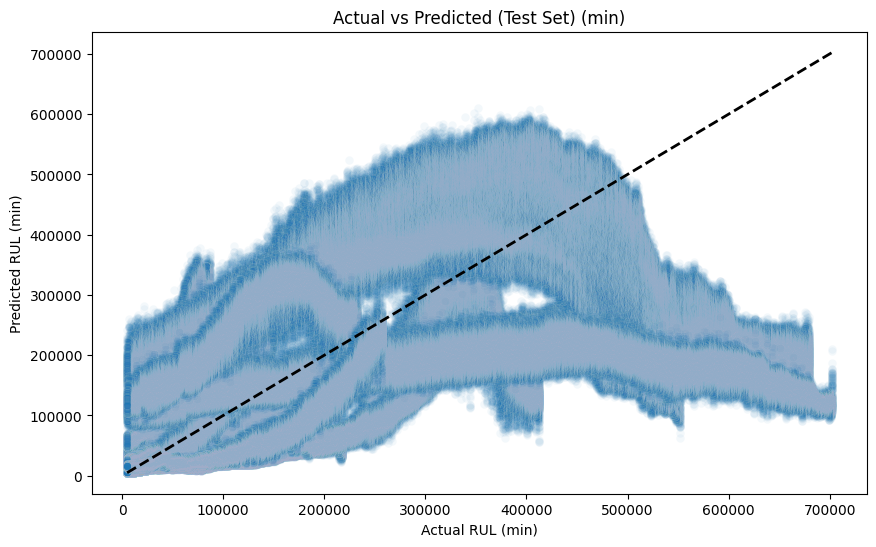

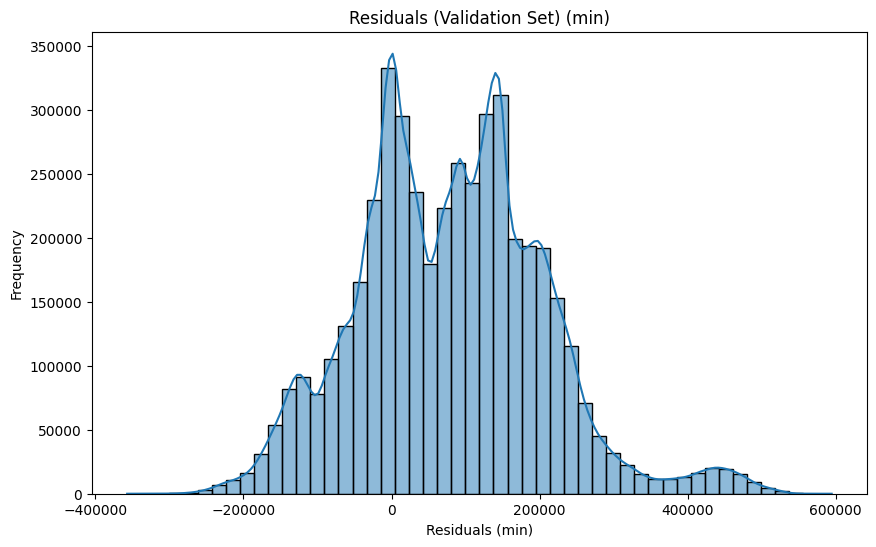

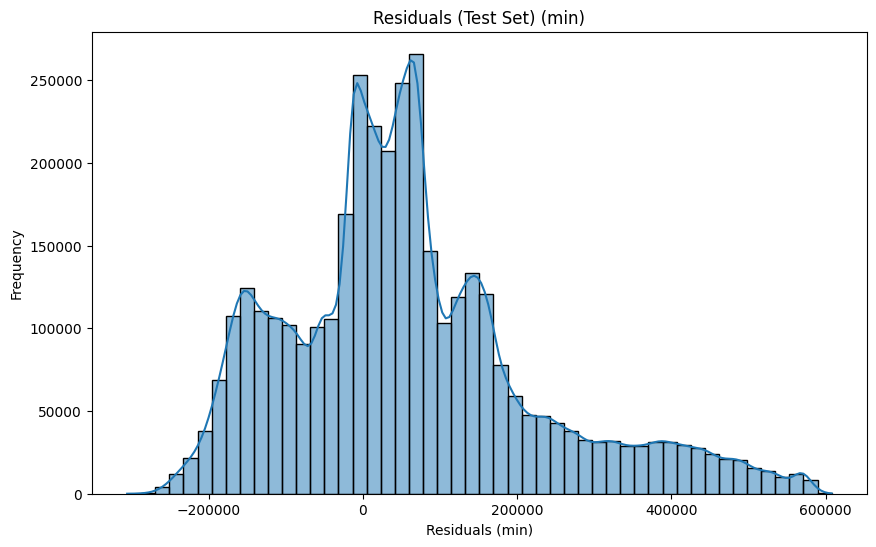

In [24]:
# 7B / Model Visualization - Feature Importance & predictions
print_header("7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL")

# keep existing helper plotting functions intact
def plot_actual_vs_predicted(y_true, y_pred, title, unit_label="minutes"):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.05)
    mn, mx = np.nanmin(y_true), np.nanmax(y_true)
    plt.plot([mn, mx], [mn, mx], 'k--', lw=2)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Actual RUL ({unit_label})')
    plt.ylabel(f'Predicted RUL ({unit_label})')
    plt.show()

def plot_residuals(y_true, y_pred, title, unit_label="minutes"):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=50, kde=True)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Residuals ({unit_label})')
    plt.ylabel('Frequency')
    plt.show()

# prepare importance series for comparison
global_importances = importances.copy()  # XGBoost computed importances across full candidate set
global_normalized = global_importances / global_importances.sum()

base_model_importances = global_importances.reindex(base_model_features).fillna(0)
base_sum = base_model_importances.sum()
if base_sum > 0:
    base_normalized = base_model_importances / base_sum
else:
    base_normalized = base_model_importances

# quick text diagnostics
print("Top global importances (first 15):")
print(global_importances.head(15))
absent_top_global = [f for f in global_importances.head(10).index if f not in base_model_features]
print("\nGlobal top features missing in base model features:")
print(absent_top_global)
print("\nTop base model features after reindexing and normalization (first 15):")
print(base_normalized.sort_values(ascending=False).head(15))

# plotting side by side for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(base_model_features) * 0.2)))

# left plot global top20 normalized
topn = 20
global_plot = global_normalized.head(topn)
sns.barplot(x=global_plot.values[::-1], y=global_plot.index[::-1], ax=axes[0], palette="Blues_r")
axes[0].set_title("Global importances normalized (top 20)")
axes[0].set_xlabel("Relative importance")

# right plot base model normalized (all base features sorted)
base_plot = base_normalized.sort_values(ascending=False)
sns.barplot(x=base_plot.values[::-1], y=base_plot.index[::-1], ax=axes[1], palette="Greens_r")
axes[1].set_title("Base model importances normalized")
axes[1].set_xlabel("Relative importance within base features")

plt.tight_layout()
plt.show()

# show predictions and residuals as before
plot_actual_vs_predicted(y_val_true_min, val_pred_min, 'Actual vs Predicted (Validation Set)', unit_label="min")
plot_actual_vs_predicted(y_test_true_min, test_pred_min, 'Actual vs Predicted (Test Set)', unit_label="min")

plot_residuals(y_val_true_min, val_pred_min, 'Residuals (Validation Set)', unit_label="min")
plot_residuals(y_test_true_min, test_pred_min, 'Residuals (Test Set)', unit_label="min")


## 8) Two Stage Models

### 8.1) STAGE 1 - Critical Region Classification

In [25]:
# 8/ Stage-1 Critical Region Classification
print_header("8/ STAGE-1 CRITICAL REGION CLASSIFICATION")

# Stage-1 threshold: boundary between NON_CRITICAL and CRITICAL
# Based on architecture: CRITICAL regime starts at RUL <= 600 minutes
STAGE1_THRESHOLD_MIN = 600

print("Purpose: Detect transition to CRITICAL regime (action required)")
print(f"Stage-1 threshold: RUL <= {STAGE1_THRESHOLD_MIN} minutes -> CRITICAL (1)")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"

print("\nDefining Stage-1 targets on Short-Life dataset...")

def define_stage1_target(y_values, threshold=STAGE1_THRESHOLD_MIN):
    return (y_values <= threshold).astype(int)

y_train_stage1 = define_stage1_target(y_train_short)
y_val_stage1   = define_stage1_target(y_val_short)
y_test_stage1  = define_stage1_target(y_test_short)

X_train_stage1 = X_train_short.copy()
X_val_stage1   = X_val_short.copy()
X_test_stage1  = X_test_short.copy()

print("Stage-1 dataset shapes:")
print(f"  Train X: {X_train_stage1.shape} | y: {y_train_stage1.shape}")
print(f"  Val   X: {X_val_stage1.shape}   | y: {y_val_stage1.shape}")
print(f"  Test  X: {X_test_stage1.shape}  | y: {y_test_stage1.shape}")

print("\nStage-1 class distribution (train):")
class_counts = y_train_stage1.value_counts()
print(f"  NON_CRITICAL (0): {class_counts.get(0, 0):,} samples ({class_counts.get(0, 0)/len(y_train_stage1)*100:.2f}%)")
print(f"  CRITICAL (1)    : {class_counts.get(1, 0):,} samples ({class_counts.get(1, 0)/len(y_train_stage1)*100:.2f}%)")

# Calculate imbalance ratio
neg_count_s1 = (y_train_stage1 == 0).sum()
pos_count_s1 = (y_train_stage1 == 1).sum()
imbalance_ratio_s1 = neg_count_s1 / max(pos_count_s1, 1)
capped_ratio_s1 = min(imbalance_ratio_s1, 5.0)

print(f"\nClass imbalance ratio: {imbalance_ratio_s1:.2f}:1")
print(f"Using scale_pos_weight: {capped_ratio_s1:.2f}")

print("\nTraining Stage-1 classifier...")

stage1_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=capped_ratio_s1,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=4,
    verbosity=0
)

stage1_model.fit(
    X_train_stage1,
    y_train_stage1,
    eval_set=[(X_val_stage1, y_val_stage1)],
    verbose=False
)

print("Evaluating Stage-1 classifier...")

y_val_pred_stage1 = stage1_model.predict(X_val_stage1)
y_val_prob_stage1 = predict_proba_in_batches(stage1_model, X_val_stage1, batch_size=5000)

print("\nValidation classification report:")
print(classification_report(y_val_stage1, y_val_pred_stage1, digits=4,
                           target_names=["NON_CRITICAL", "CRITICAL"]))

val_auc_stage1 = roc_auc_score(y_val_stage1, y_val_prob_stage1)
print(f"Validation ROC AUC: {val_auc_stage1:.4f}")

# DEBUG: Check predictions
print(f"\n[TEMP:DEBUG] Stage-1 prediction distribution:")
print(f"  NON_CRITICAL: {(y_val_pred_stage1 == 0).sum()}")
print(f"  CRITICAL: {(y_val_pred_stage1 == 1).sum()}")

# Save Model
joblib_path = os.path.join(save_path, "hydraulic_press_stage1_classifier.pkl")
joblib.dump(stage1_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

print_footer("STAGE-1 CLASSIFICATION COMPLETE")


8/ STAGE-1 CRITICAL REGION CLASSIFICATION
Purpose: Detect transition to CRITICAL regime (action required)
Stage-1 threshold: RUL <= 600 minutes -> CRITICAL (1)

Defining Stage-1 targets on Short-Life dataset...
Stage-1 dataset shapes:
  Train X: (344084, 30) | y: (344084,)
  Val   X: (62864, 30)   | y: (62864,)
  Test  X: (61821, 30)  | y: (61821,)

Stage-1 class distribution (train):
  NON_CRITICAL (0): 264,049 samples (76.74%)
  CRITICAL (1)    : 80,035 samples (23.26%)

Class imbalance ratio: 3.30:1
Using scale_pos_weight: 3.30

Training Stage-1 classifier...
Evaluating Stage-1 classifier...

Validation classification report:
              precision    recall  f1-score   support

NON_CRITICAL     0.9775    0.9806    0.9791     45324
    CRITICAL     0.9495    0.9417    0.9456     17540

    accuracy                         0.9698     62864
   macro avg     0.9635    0.9612    0.9623     62864
weighted avg     0.9697    0.9698    0.9697     62864

Validation ROC AUC: 0.9938

[TEMP:D

### 8.2) STAGE 2A - Critical Regression

In [26]:
# 8A/ Stage-2A Critical RUL Regression
print_header("8A/ STAGE-2A CRITICAL RUL REGRESSION")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-2A operating range: RUL <= 5000 min (aligned with NEAR_TERM threshold)
# Critical focus: High accuracy for RUL <= 1500 min, best accuracy for RUL <= 600 min
STAGE2A_MAX_RUL_MIN = 5000

print("Purpose: High-resolution RUL prediction in NEAR_TERM/CRITICAL regime")
print(f"Stage-2A operating range: RUL <= {STAGE2A_MAX_RUL_MIN} minutes")
print(f"Critical focus: RUL <= 1500 min (high accuracy), RUL <= 600 min (best accuracy)")

print("\nFiltering samples for Stage-2A...")

def filter_stage2a_samples(df, y_values, max_rul=STAGE2A_MAX_RUL_MIN):
    mask = y_values <= max_rul
    return df[mask].copy(), y_values[mask].copy()

X_train_stage2a, y_train_stage2a_raw = filter_stage2a_samples(X_train_short, y_train_short)
X_val_stage2a, y_val_stage2a_raw = filter_stage2a_samples(X_val_short, y_val_short)
X_test_stage2a, y_test_stage2a_raw = filter_stage2a_samples(X_test_short, y_test_short)

# Also keep df subsets for cycle_id access later
df_train_stage2a = df_train_short[y_train_short <= STAGE2A_MAX_RUL_MIN].copy()
df_val_stage2a = df_val_short[y_val_short <= STAGE2A_MAX_RUL_MIN].copy()
df_test_stage2a = df_test_short[y_test_short <= STAGE2A_MAX_RUL_MIN].copy()

assert len(X_train_stage2a) > 0, "No training samples in Stage-2A range"
assert len(X_val_stage2a) > 0, "No validation samples in Stage-2A range"
assert len(X_test_stage2a) > 0, "No test samples in Stage-2A range"

print("Stage-2A dataset shapes:")
print(f"  Train: {X_train_stage2a.shape}")
print(f"  Val  : {X_val_stage2a.shape}")
print(f"  Test : {X_test_stage2a.shape}")

# DEBUG: Check RUL distribution in Stage-2A data
print(f"\n[TEMP:DEBUG] Stage-2A train RUL range: {y_train_stage2a_raw.min()} - {y_train_stage2a_raw.max()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 600: {(y_train_stage2a_raw <= 600).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 300: {(y_train_stage2a_raw <= 300).sum()}")
print(f"[TEMP:DEBUG] Samples with RUL <= 100: {(y_train_stage2a_raw <= 100).sum()}")

print("\nUsing ALL selected features for Stage-2A...")
print("  Reason: More features provide better context for accurate predictions")

# Use all selected features (not just a subset)
stage2a_features = selected_features.copy()
print(f"  Feature count: {len(stage2a_features)}")

X_train_stage2a = X_train_stage2a[stage2a_features]
X_val_stage2a   = X_val_stage2a[stage2a_features]
X_test_stage2a  = X_test_stage2a[stage2a_features]

# Target transformation: log1p for stable learning
print("\nTransforming targets to log-space...")
y_train_stage2a = np.log1p(y_train_stage2a_raw.values)
y_val_stage2a   = np.log1p(y_val_stage2a_raw.values)
y_test_stage2a  = np.log1p(y_test_stage2a_raw.values)

print("Computing decision-aligned sample weights...")
print("  Higher weight for samples closer to failure (RUL -> 0)")
print("  Weight range: 1.0 - 10.0")

def compute_decision_aligned_weights(rul_values, max_rul=STAGE2A_MAX_RUL_MIN):
    """
    Compute sample weights that prioritize critical samples.
    Samples closer to failure get exponentially higher weights.
    """
    normalized_distance = np.clip(rul_values / max_rul, 0.0, 1.0)
    
    # Exponential decay from max_weight to 1.0 as RUL increases
    max_weight = 10.0
    min_weight = 1.0
    
    # Use exponential weighting: closer to 0 = higher weight
    weights = min_weight + (max_weight - min_weight) * np.exp(-3.0 * normalized_distance)
    
    # Extra boost for very critical samples (RUL <= 300)
    very_critical_mask = rul_values <= 300
    weights[very_critical_mask] *= 1.5
    
    # Extra boost for extreme critical samples (RUL <= 100)
    extreme_critical_mask = rul_values <= 100
    weights[extreme_critical_mask] *= 1.5
    
    return np.clip(weights, min_weight, max_weight * 2)

train_sample_weights = compute_decision_aligned_weights(y_train_stage2a_raw.values)
val_sample_weights   = compute_decision_aligned_weights(y_val_stage2a_raw.values)

print(f"  Very critical (<150 min) avg weight: {train_sample_weights[y_train_stage2a_raw <= 150].mean():.1f}")

assert len(train_sample_weights) == len(y_train_stage2a)
assert len(val_sample_weights) == len(y_val_stage2a)

print("\nTraining weighted Stage-2A regressor...")

# Build monotonic constraints for degradation-related features
monotone_constraints = []
for feat in stage2a_features:
    # Features that should increase with degradation (negative correlation with RUL)
    if any(kw in feat for kw in ['vibration', 'temperature', 'contamination', 'current', 'degradation']):
        if 'pressure' not in feat:  # pressure decreases with degradation
            monotone_constraints.append(-1)
        else:
            monotone_constraints.append(0)
    # Features that should decrease with degradation (positive correlation with RUL)
    elif any(kw in feat for kw in ['pressure', 'force', 'flow']):
        if 'ratio' not in feat and 'coupling' not in feat:
            monotone_constraints.append(1)
        else:
            monotone_constraints.append(0)
    else:
        monotone_constraints.append(0)

n_monotonic = sum(1 for x in monotone_constraints if x != 0)
print(f"  Monotonic constraints applied: {n_monotonic} features")

stage2a_model = XGBRegressor(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_alpha=0.3,
    reg_lambda=1.5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=4,
    verbosity=0,
    monotone_constraints=tuple(monotone_constraints)
)

stage2a_model.fit(
    X_train_stage2a,
    y_train_stage2a,
    sample_weight=train_sample_weights,
    eval_set=[(X_val_stage2a, y_val_stage2a)],
    sample_weight_eval_set=[val_sample_weights],
    early_stopping_rounds=100,
    verbose=False
)

print(f"  Best iteration: {stage2a_model.best_iteration}")
print("Evaluating Stage-2A regressor...")

# Predictions in log-domain, inverse-transform to minutes
val_pred_log = stage2a_model.predict(X_val_stage2a)
val_predictions = np.expm1(val_pred_log)

test_pred_log = stage2a_model.predict(X_test_stage2a)
test_predictions = np.expm1(test_pred_log)

# Decision-aware clipping per cycle
val_window_max = df_val_stage2a.groupby('cycle_id')["current_rul"].transform('max').values
test_window_max = df_test_stage2a.groupby('cycle_id')["current_rul"].transform('max').values

val_predictions = np.clip(val_predictions, 0.0, val_window_max)
test_predictions = np.clip(test_predictions, 0.0, test_window_max)

# Evaluate against raw minute-scale targets
val_mae = MAE(y_val_stage2a_raw, val_predictions)
val_rmse = MSE(y_val_stage2a_raw, val_predictions, squared=False)
val_r2 = r2_score(y_val_stage2a_raw, val_predictions)

test_mae = MAE(y_test_stage2a_raw, test_predictions)
test_rmse = MSE(y_test_stage2a_raw, test_predictions, squared=False)
test_r2 = r2_score(y_test_stage2a_raw, test_predictions)

print("\nValidation Metrics:")
print(f"  MAE  : {val_mae:.2f} min")
print(f"  RMSE : {val_rmse:.2f} min")
print(f"  R2   : {val_r2 * 100:.2f}%")

print("\nTest Metrics:")
print(f"  MAE  : {test_mae:.2f} min")
print(f"  RMSE : {test_rmse:.2f} min")
print(f"  R2   : {test_r2 * 100:.2f}%")

# Critical region analysis
print("\n=== CRITICAL REGION ANALYSIS ===")

critical_thresholds = [
    (300, "Very Critical (RUL <= 300 min)"),
    (150, "Extreme Critical (RUL <= 150 min)"),
    (600, "Approaching Critical (300-600 min)", 300)  # Range check
]

for item in critical_thresholds:
    if len(item) == 2:
        threshold, label = item
        mask = y_test_stage2a_raw <= threshold
    else:
        threshold, label, lower = item
        mask = (y_test_stage2a_raw > lower) & (y_test_stage2a_raw <= threshold)
    
    if mask.sum() > 0:
        region_mae = MAE(y_test_stage2a_raw[mask], test_predictions[mask])
        region_r2 = r2_score(y_test_stage2a_raw[mask], test_predictions[mask])
        print(f"{label}: {mask.sum()} samples")
        print(f"  MAE: {region_mae:.2f} min | R2: {region_r2*100:.1f}%")

# Save model
joblib_path = os.path.join(save_path, "hydraulic_press_stage2a_regressor.pkl")
joblib.dump(stage2a_model, joblib_path, compress=('lz4', 3))  
print(f"\nModel saved (joblib): {joblib_path}")

print_footer("STAGE-2A CRITICAL RUL REGRESSION COMPLETE")


8A/ STAGE-2A CRITICAL RUL REGRESSION
Purpose: High-resolution RUL prediction in NEAR_TERM/CRITICAL regime
Stage-2A operating range: RUL <= 5000 minutes
Critical focus: RUL <= 1500 min (high accuracy), RUL <= 600 min (best accuracy)

Filtering samples for Stage-2A...
Stage-2A dataset shapes:
  Train: (344084, 30)
  Val  : (62864, 30)
  Test : (61821, 30)

[TEMP:DEBUG] Stage-2A train RUL range: 0 - 4993
[TEMP:DEBUG] Samples with RUL <= 600: 80035
[TEMP:DEBUG] Samples with RUL <= 300: 41505
[TEMP:DEBUG] Samples with RUL <= 100: 14140

Using ALL selected features for Stage-2A...
  Reason: More features provide better context for accurate predictions
  Feature count: 30

Transforming targets to log-space...
Computing decision-aligned sample weights...
  Higher weight for samples closer to failure (RUL -> 0)
  Weight range: 1.0 - 10.0
  Very critical (<150 min) avg weight: 18.0

Training weighted Stage-2A regressor...
  Monotonic constraints applied: 26 features
  Best iteration: 307
Evalua

## 9) Two Stage Inference & Evaluation

In [ ]:
# 9/ TWO-STAGE INFERENCE AND EVALUATION
print_header("9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE")

# Architecture Overview:
# Stage-0: LONG_TERM vs NEAR_TERM regime detection (trained on Long-Life)
# Stage-1: NON_CRITICAL vs CRITICAL detection (trained on Short-Life)
# Base Model: Long-term RUL tracking (LONG_TERM + transition regime)
# Stage-2A: High-resolution critical RUL (CRITICAL regime only)

# Preconditions
assert 'stage0_model' in globals(), "Stage-0 classifier not found"
assert 'stage1_model' in globals(), "Stage-1 classifier not found"
assert 'base_model' in globals(), "Base Model regressor not found"
assert 'stage2a_model' in globals(), "Stage-2A regressor not found"
assert 'base_model_features' in globals(), "base_model_features not found"
assert 'stage2a_features' in globals(), "stage2a_features not found"


# PART A: BASE MODEL + STAGE-0 EVALUATION (LONG-LIFE TEST SET)
print("\n" + "=" * 60)
print("PART A: BASE MODEL + STAGE-0 (Long-Life Test Set)")
print("=" * 60)

X_eval_long = X_test_long.copy()
y_eval_long = y_test_long.copy()

print(f"Long-Life Evaluation set: {len(y_eval_long):,} samples")
print(f"RUL range: {y_eval_long.min():.0f} - {y_eval_long.max():.0f} minutes")

# STAGE-0: Regime Detection
print("\n[Stage-0] Regime detection (LONG_TERM vs NEAR_TERM)...")
stage0_prob_long = predict_proba_in_batches(stage0_model, X_eval_long, batch_size=5000)
stage0_pred_long = (stage0_prob_long >= 0.5).astype(int)
n_long_term = (stage0_pred_long == 0).sum()
n_near_term = (stage0_pred_long == 1).sum()
print(f"  LONG_TERM: {n_long_term:,} | NEAR_TERM: {n_near_term:,}")

# BASE MODEL: Default prediction for all samples (Long-Life context)
print("\n[Base Model] Long-term RUL tracking...")

missing_base = [c for c in base_model_features if c not in X_eval_long.columns]
if len(missing_base) > 0:
    raise ValueError(f"Missing base model features: {missing_base}")

base_pred_log_long = base_model.predict(X_eval_long[base_model_features])
base_pred_hr_long = np.expm1(base_pred_log_long)
base_pred_min_long = base_pred_hr_long * 60.0

# Base Model Metrics
base_mae_long = MAE(y_eval_long, base_pred_min_long)
base_r2_long = r2_score(y_eval_long, base_pred_min_long)
print(f"  Base Model MAE: {base_mae_long:.2f} min")
print(f"  Base Model R2 : {base_r2_long*100:.2f}%")

# Stratified Analysis (Base Model on Long-Life)
print("\nBase Model Stratified Performance (Long-Life):")
print(f"{'RUL Range':<20} {'N':>8} {'MAE':>10} {'Rel.Err':>10}")
print("-" * 50)

bins_long = [
                (5000, 20000, "Mid Term"),
                (20000, 100000, "Long Term"),
                (100000, float('inf'), "Very Long Term")
            ]

for low, high, label in bins_long:
    mask = (y_eval_long >= low) & (y_eval_long < high)
    if mask.sum() == 0:
        continue
    bin_mae = MAE(y_eval_long[mask], base_pred_min_long[mask])
    avg_rul = y_eval_long[mask].mean()
    rel_err = (bin_mae / avg_rul) * 100 if avg_rul > 0 else 0
    print(f"{label:<20} {mask.sum():>8,} {bin_mae:>10.2f} {rel_err:>9.1f}%")



# PART B: STAGE-1 + STAGE-2A EVALUATION (SHORT-LIFE TEST SET)
print("\n" + "=" * 60)
print("PART B: STAGE-1 + STAGE-2A (Short-Life Test Set)")
print("=" * 60)

X_eval_short = X_test_short.copy()
y_eval_short = y_test_short.copy()

print(f"Short-Life Evaluation set: {len(y_eval_short):,} samples")
print(f"RUL range: {y_eval_short.min():.0f} - {y_eval_short.max():.0f} minutes")

# STAGE-1: Critical Detection (only valid for Short-Life context)
print("\n[Stage-1] Critical detection (NON_CRITICAL vs CRITICAL)...")

THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2

critical_prob_short = predict_proba_in_batches(stage1_model, X_eval_short, batch_size=5000)

critical_flag_short = np.zeros_like(critical_prob_short, dtype=int)
critical_flag_short[critical_prob_short >= THRESH_ENTER] = 1
critical_flag_short[critical_prob_short <= THRESH_EXIT]  = 0
critical_flag_short[(critical_prob_short > THRESH_EXIT) & (critical_prob_short < THRESH_ENTER)] = -1

n_critical = (critical_flag_short == 1).sum()
n_non_critical = (critical_flag_short == 0).sum()
n_uncertain = (critical_flag_short == -1).sum()
print(f"  CRITICAL: {n_critical:,} | NON_CRITICAL: {n_non_critical:,} | UNCERTAIN: {n_uncertain:,}")


final_pred_short = np.full(len(X_eval_short), np.nan, dtype=float)

# BASE MODEL: Fallback for NON_CRITICAL and UNCERTAIN samples
print("\n[Base Model] Fallback for NON_CRITICAL and UNCERTAIN samples...")

idx_non_critical_short = np.where(critical_flag_short != 1)[0]

if len(idx_non_critical_short) > 0:
    missing_base_short = [c for c in base_model_features if c not in X_eval_short.columns]
    if len(missing_base_short) > 0:
        raise ValueError(f"Missing base model features: {missing_base_short}")
    
    X_non_crit_short = X_eval_short.iloc[idx_non_critical_short][base_model_features]
    
    base_pred_log_short = base_model.predict(X_non_crit_short)
    base_pred_hr_short = np.expm1(base_pred_log_short)
    base_pred_min_short = base_pred_hr_short * 60.0
    
    final_pred_short[idx_non_critical_short] = base_pred_min_short
    print(f"  Applied Base Model to {len(idx_non_critical_short):,} non-critical samples")
else:
    print("  All samples are critical, no fallback needed")

# STAGE-2A: Override for CRITICAL samples
print("\n[Stage-2A] Critical RUL refinement (Short-Life)...")

idx_critical_short = np.where(critical_flag_short == 1)[0]

if len(idx_critical_short) > 0:
    missing_s2a = [c for c in stage2a_features if c not in X_eval_short.columns]
    if len(missing_s2a) > 0:
        raise ValueError(f"Missing Stage-2A features: {missing_s2a}")
    
    X_crit_short = X_eval_short.iloc[idx_critical_short][stage2a_features]
    
    pred_2a_log_short = stage2a_model.predict(X_crit_short)
    pred_2a_short = np.expm1(pred_2a_log_short)
    pred_2a_short = np.clip(pred_2a_short, 0.0, STAGE2A_MAX_RUL_MIN)
    
    final_pred_short[idx_critical_short] = pred_2a_short
    print(f"  Applied Stage-2A to {len(idx_critical_short):,} critical samples")
else:
    print("  No critical samples detected by Stage-1")

# Verify no NaN values remain
nan_count = np.isnan(final_pred_short).sum()
if nan_count > 0:
    print(f"  WARNING: {nan_count} samples still have NaN predictions")
else:
    print(f"  All {len(final_pred_short):,} samples have valid predictions")

final_pred_short = np.clip(final_pred_short, 0, 720000)

# FINAL EVALUATION: CRITICAL REGION ON SHORT-LIFE
print("\n" + "=" * 60)
print("FINAL SYSTEM PERFORMANCE (SHORT-LIFE TEST SET)")
print("=" * 60)

final_mae_short = MAE(y_eval_short, final_pred_short)
final_rmse_short = R_MSE(y_eval_short, final_pred_short)
final_r2_short = r2_score(y_eval_short, final_pred_short)

print(f"\nOverall Metrics (Short-Life):")
print(f"  MAE : {final_mae_short:.2f} min")
print(f"  RMSE: {final_rmse_short:.2f} min")
print(f"  R2  : {final_r2_short*100:.2f}%")

# Stratified Analysis
print("\nStratified Performance (Short-Life):")
print(f"{'RUL Range':<20} {'N':>8} {'MAE':>10} {'Rel.Err':>10}")
print("-" * 50)

bins_short = [
                (0, 100, "Very Critical"),
                (100, 300, "Critical"),
                (300, 600, "Near Critical"),
                (600, 1500, "Transition"),
                (1500, float('inf'), "Beyond Critical")
            ]

for low, high, label in bins_short:
    mask = (y_eval_short >= low) & (y_eval_short < high)
    if mask.sum() == 0:
        continue
    
    bin_mae = MAE(y_eval_short[mask], final_pred_short[mask])
    avg_rul = y_eval_short[mask].mean()
    rel_err = (bin_mae / avg_rul) * 100 if avg_rul > 0 else 0
    
    print(f"{label:<20} {mask.sum():>8,} {bin_mae:>10.2f} {rel_err:>9.1f}%")

# Critical Region Metrics (Project Target on Short-Life)
print("\n" + "=" * 60)
print("CRITICAL REGION ANALYSIS (RUL <= 600 min) - SHORT-LIFE")
print("=" * 60)

crit_mask_short = y_eval_short <= 600
n_crit_short = crit_mask_short.sum()

if n_crit_short > 0:
    crit_mae_short = MAE(y_eval_short[crit_mask_short], final_pred_short[crit_mask_short])
    crit_acc_10min_short = (np.abs(y_eval_short[crit_mask_short] - final_pred_short[crit_mask_short]) <= ACCURACY_TOLERANCE).mean() * 100
    crit_acc_40min_short = (np.abs(y_eval_short[crit_mask_short] - final_pred_short[crit_mask_short]) <= 40).mean() * 100
    
    print(f"  Samples        : {n_crit_short:,}")
    print(f"  MAE            : {crit_mae_short:.2f} min (target: < 40 min)")
    print(f"  +/- 10 min acc : {crit_acc_10min_short:.1f}%")
    print(f"  +/- 40 min acc : {crit_acc_40min_short:.1f}% (target: > 60%)")
    
    very_crit_mask_short = y_eval_short <= 300
    if very_crit_mask_short.sum() > 0:
        very_crit_mae_short = MAE(y_eval_short[very_crit_mask_short], final_pred_short[very_crit_mask_short])
        print(f"\n  Very Critical (RUL <= 300):")
        print(f"    Samples: {very_crit_mask_short.sum():,}")
        print(f"    MAE    : {very_crit_mae_short:.2f} min")
else:
    print("  No critical samples in Short-Life test set")

# Store for sanity check cell
final_pred = final_pred_short
X_eval = X_eval_short
y_eval = y_eval_short

print_footer("FINAL TWO-STAGE PIPELINE COMPLETE")

## 10) Sanity Checks

In [ ]:
# 10/ SANITY CHECKS - Multi-Resolution RUL System
print_header("10/ SANITY CHECKS - Hydraulic Press Multi-Resolution RUL Pipeline")

# Preconditions
assert 'stage0_model' in globals(), "Stage-0 classifier missing"
assert 'stage1_model' in globals(), "Stage-1 classifier missing"
assert 'base_model' in globals(), "Base Model regressor missing"
assert 'stage2a_model' in globals(), "Stage-2A regressor missing"

# Hysteresis thresholds
THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2


# STAGE-0 SANITY CHECK (Long-Life Test Set)
print("\n=== STAGE-0: REGIME DETECTOR (LONG_TERM vs NEAR_TERM) ===")
print(f"Test data: Long-Life (threshold: RUL <= {STAGE0_THRESHOLD_MIN} min)")

y_test_regime_true = (y_test_long <= STAGE0_THRESHOLD_MIN).astype(int)
y_test_regime_prob = predict_proba_in_batches(stage0_model, X_test_long, batch_size=5000)
y_test_regime_pred = (y_test_regime_prob >= 0.5).astype(int)

regime_tp = ((y_test_regime_pred == 1) & (y_test_regime_true == 1)).sum()
regime_fn = ((y_test_regime_pred == 0) & (y_test_regime_true == 1)).sum()
regime_fp = ((y_test_regime_pred == 1) & (y_test_regime_true == 0)).sum()
regime_tn = ((y_test_regime_pred == 0) & (y_test_regime_true == 0)).sum()

regime_recall = regime_tp / (regime_tp + regime_fn) if (regime_tp + regime_fn) > 0 else 0.0
regime_precision = regime_tp / (regime_tp + regime_fp) if (regime_tp + regime_fp) > 0 else 0.0

print(f"True Positives (NEAR_TERM correct): {regime_tp:,}")
print(f"False Negatives (missed NEAR_TERM): {regime_fn:,}")
print(f"False Positives (wrong NEAR_TERM):  {regime_fp:,}")
print(f"True Negatives (LONG_TERM correct): {regime_tn:,}")
print(f"\nNEAR_TERM Recall   : {regime_recall:.3f}")
print(f"NEAR_TERM Precision: {regime_precision:.3f}")

stage0_pass = regime_recall >= 0.80
print(f"Stage-0 verdict    : {'PASS' if stage0_pass else 'FAIL'} (target recall >= 0.80)")



# STAGE-1 SANITY CHECK (Short-Life Test Set)
print("\n=== STAGE-1: CRITICAL DETECTOR (NON_CRITICAL vs CRITICAL) ===")
print(f"Test data: Short-Life (threshold: RUL <= {STAGE1_THRESHOLD_MIN} min)")

y_test_crit_true_short = (y_test_short <= STAGE1_THRESHOLD_MIN).astype(int)
y_test_crit_prob_short = predict_proba_in_batches(stage1_model, X_test_short, batch_size=5000)

y_test_crit_pred_short = np.zeros_like(y_test_crit_prob_short, dtype=int)
y_test_crit_pred_short[y_test_crit_prob_short >= THRESH_ENTER] = 1
y_test_crit_pred_short[y_test_crit_prob_short <= THRESH_EXIT]  = 0

known_mask_short = (y_test_crit_prob_short >= THRESH_ENTER) | (y_test_crit_prob_short <= THRESH_EXIT)

tp_short = ((y_test_crit_pred_short == 1) & (y_test_crit_true_short == 1) & known_mask_short).sum()
fn_short = ((y_test_crit_pred_short == 0) & (y_test_crit_true_short == 1) & known_mask_short).sum()
fp_short = ((y_test_crit_pred_short == 1) & (y_test_crit_true_short == 0) & known_mask_short).sum()

crit_recall_short = tp_short / (tp_short + fn_short) if (tp_short + fn_short) > 0 else 0.0
crit_precision_short = tp_short / (tp_short + fp_short) if (tp_short + fp_short) > 0 else 0.0
fnr_short = fn_short / (tp_short + fn_short) if (tp_short + fn_short) > 0 else 0.0

print(f"Critical Recall      : {crit_recall_short:.3f}")
print(f"Critical Precision   : {crit_precision_short:.3f}")
print(f"False Negative Rate  : {fnr_short:.3f}")

stage1_pass = crit_recall_short >= 0.85
print(f"Stage-1 verdict      : {'PASS' if stage1_pass else 'FAIL'} (target recall >= 0.85)")



# STAGE-2A SANITY CHECK (Short-Life Test Set)
print("\n=== STAGE-2A: CRITICAL REGRESSOR ===")
print(f"Test data: Short-Life (operating range: RUL <= {STAGE2A_MAX_RUL_MIN} min)")

mask_very_critical_short = y_test_short <= 300
mask_critical_short = y_test_short <= 600
mask_near_critical_short = y_test_short <= 1500

if mask_very_critical_short.sum() > 0:
    X_test_s2a_vc_short = X_test_short[mask_very_critical_short][stage2a_features]
    y_test_s2a_vc_short = y_test_short[mask_very_critical_short]
    pred_s2a_vc_log_short = stage2a_model.predict(X_test_s2a_vc_short)
    pred_s2a_vc_short = np.expm1(pred_s2a_vc_log_short)
    mae_s2a_vc_short = MAE(y_test_s2a_vc_short, pred_s2a_vc_short)
    print(f"Very Critical (<= 300 min): {mask_very_critical_short.sum():,} samples | MAE: {mae_s2a_vc_short:.2f} min")
    stage2a_pass_strict = mae_s2a_vc_short <= 40.0
else:
    print("No very critical samples in Short-Life test set")
    stage2a_pass_strict = True

if mask_critical_short.sum() > 0:
    X_test_s2a_c_short = X_test_short[mask_critical_short][stage2a_features]
    y_test_s2a_c_short = y_test_short[mask_critical_short]
    pred_s2a_c_log_short = stage2a_model.predict(X_test_s2a_c_short)
    pred_s2a_c_short = np.expm1(pred_s2a_c_log_short)
    mae_s2a_c_short = MAE(y_test_s2a_c_short, pred_s2a_c_short)
    print(f"Critical (<= 600 min)     : {mask_critical_short.sum():,} samples | MAE: {mae_s2a_c_short:.2f} min")
    stage2a_pass_relaxed = mae_s2a_c_short <= 60.0
else:
    print("No critical samples in Short-Life test set")
    stage2a_pass_relaxed = True

if mask_near_critical_short.sum() > 0:
    X_test_s2a_nc_short = X_test_short[mask_near_critical_short][stage2a_features]
    y_test_s2a_nc_short = y_test_short[mask_near_critical_short]
    pred_s2a_nc_log_short = stage2a_model.predict(X_test_s2a_nc_short)
    pred_s2a_nc_short = np.expm1(pred_s2a_nc_log_short)
    mae_s2a_nc_short = MAE(y_test_s2a_nc_short, pred_s2a_nc_short)
    print(f"Near Critical (<= 1500 min): {mask_near_critical_short.sum():,} samples | MAE: {mae_s2a_nc_short:.2f} min")

stage2a_pass = stage2a_pass_strict and stage2a_pass_relaxed
print(f"Stage-2A verdict     : {'PASS' if stage2a_pass else 'FAIL'}")



# FINAL SYSTEM SANITY CHECK (Short-Life)
print("\n=== FINAL SYSTEM (CRITICAL FOCUS - SHORT-LIFE) ===")

crit_proj = PROJECT_CRITICAL_THRESHOLD  # 100 min
mask_crit_final_short = y_test_short <= crit_proj

if mask_crit_final_short.sum() > 0:
    final_mae_crit_short = MAE(y_test_short[mask_crit_final_short], final_pred[mask_crit_final_short])
    final_acc_tol_short = (np.abs(y_test_short[mask_crit_final_short] - final_pred[mask_crit_final_short]) <= ACCURACY_TOLERANCE).mean() * 100
    final_acc_40_short = (np.abs(y_test_short[mask_crit_final_short] - final_pred[mask_crit_final_short]) <= 40).mean() * 100
    
    print(f"Samples (<= {crit_proj} min)  : {mask_crit_final_short.sum():,}")
    print(f"MAE                   : {final_mae_crit_short:.2f} min (target < 40)")
    print(f"+/- {ACCURACY_TOLERANCE} min accuracy : {final_acc_tol_short:.1f}%")
    print(f"+/- 40 min accuracy   : {final_acc_40_short:.1f}% (target > 60%)")
    
    final_system_pass = final_acc_40_short >= 60.0
else:
    print("No critical samples for final check in Short-Life test set")
    final_system_pass = False

print(f"Final system verdict : {'PASS' if final_system_pass else 'FAIL'}")



# DRIFT CHECK (Long-Life)
print("\n=== DRIFT CHECK (DIAGNOSTIC - Long-Life) ===")

ks_p_values = []
cols_to_check = [c for c in X_train_long.columns if pd.api.types.is_numeric_dtype(X_train_long[c])]
for col in cols_to_check:
    try:
        _, p = ks_2samp(X_train_long[col], X_test_long[col])
    except Exception:
        p = 1.0
    ks_p_values.append(p)

feature_drift_ratio = np.mean(np.array(ks_p_values) < 0.05)
_, target_p = ks_2samp(y_train_long, y_test_long)
print(f"Feature drift ratio: {feature_drift_ratio:.2f}")
print(f"Target KS p-value  : {target_p:.4f}")



# PERMUTATION IMPORTANCE (BASE MODEL)
print("\n=== PERMUTATION IMPORTANCE (BASE MODEL) ===")

def neg_mae_minutes(est, X, y_min):
    y_min = np.array(y_min, copy=True)
    preds_log = est.predict(X)
    preds_min = np.expm1(preds_log) * 60.0
    return -MAE(y_min, preds_min)

perm_res = permutation_importance(
    base_model,
    X_test_base,
    y_test_base_min.to_numpy().copy(),
    scoring=neg_mae_minutes,
    n_repeats=10,
    random_state=42,
    n_jobs=4
)
perm_importances = pd.Series(perm_res.importances_mean, index=X_test_base.columns).sort_values(ascending=False)
print("Top 10 features by permutation importance:")
for i, (feat, imp) in enumerate(perm_importances.head(10).items(), 1):
    print(f"  {i:2d}. {feat:35s} {imp:.4f}")



# FINAL SANITY SUMMARY
print("\n" + "=" * 60)
print("FINAL SANITY SUMMARY")
print("=" * 60)
print(f"Stage-0 Regime Detector   : {'PASS' if stage0_pass else 'FAIL'} (Long-Life test, threshold={STAGE0_THRESHOLD_MIN} min)")
print(f"Stage-1 Critical Detector : {'PASS' if stage1_pass else 'FAIL'} (Short-Life test, threshold={STAGE1_THRESHOLD_MIN} min)")
print(f"Stage-2A Critical Regressor: {'PASS' if stage2a_pass else 'FAIL'} (Short-Life test, range=0-{STAGE2A_MAX_RUL_MIN} min)")
print(f"Final Two-Stage System    : {'PASS' if final_system_pass else 'FAIL'} (Short-Life test)")

all_pass = stage0_pass and stage1_pass and stage2a_pass and final_system_pass
print(f"\nOVERALL SYSTEM STATUS     : {'PASS' if all_pass else 'NEEDS REVIEW'}")

print_footer("SANITY CHECKS COMPLETE")

In [ ]:
# 10A/ Multi-Resolution Pipeline Model Behavior Visualization
print_header("10A/ MODEL BEHAVIOR VISUALIZATION")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
sample_cycle_ids = df_test_short['cycle_id'].unique()[:3]
colors_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, cycle_id in enumerate(sample_cycle_ids):
    cycle_mask = df_test_short['cycle_id'] == cycle_id
    cycle_indices = np.where(cycle_mask)[0]
    
    cycle_rul = y_eval_short.iloc[cycle_indices].values
    cycle_pred = final_pred_short[cycle_indices]
    cycle_time = df_test_short.loc[cycle_mask, 'time_min'].values
    
    cycle_stage1_prob = critical_prob_short[cycle_indices]
    cycle_critical_flag = critical_flag_short[cycle_indices]
    
    ax1.plot(cycle_time, cycle_rul, '-', color=colors_cycle[idx], 
             linewidth=2, label=f'Cycle {cycle_id} - Actual RUL')
    ax1.plot(cycle_time, cycle_pred, '--', color=colors_cycle[idx], 
             linewidth=1.5, alpha=0.7, label=f'Cycle {cycle_id} - Predicted')
    
    critical_times = cycle_time[cycle_critical_flag == 1]
    critical_preds = cycle_pred[cycle_critical_flag == 1]
    if len(critical_times) > 0:
        ax1.scatter(critical_times[::10], critical_preds[::10], 
                   color='red', s=20, zorder=5, alpha=0.6)

ax1.axhline(y=STAGE1_THRESHOLD_MIN, color='red', linestyle=':', linewidth=2, 
            label=f'Critical Threshold ({STAGE1_THRESHOLD_MIN} min)')
ax1.set_xlabel('Time (minutes)', fontsize=11)
ax1.set_ylabel('RUL (minutes)', fontsize=11)
ax1.set_title('RUL Prediction Over Time - Model Switching Behavior\n(Red dots = Stage-2A active)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_yscale('log')

ax2 = axes[0, 1]
rul_sorted_idx = np.argsort(y_eval_short.values)
rul_sorted = y_eval_short.values[rul_sorted_idx]
pred_sorted = final_pred_short[rul_sorted_idx]
critical_flag_sorted = critical_flag_short[rul_sorted_idx]

base_model_mask = critical_flag_sorted != 1
stage2a_mask = critical_flag_sorted == 1

ax2.scatter(rul_sorted[base_model_mask], pred_sorted[base_model_mask], 
           alpha=0.05, s=3, c='blue', label='Base Model Predictions')
ax2.scatter(rul_sorted[stage2a_mask], pred_sorted[stage2a_mask], 
           alpha=0.1, s=5, c='red', label='Stage-2A Predictions')

max_val = max(rul_sorted.max(), pred_sorted.max())
ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect Prediction')
ax2.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
            label=f'Model Switch Point ({STAGE1_THRESHOLD_MIN} min)')

ax2.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax2.set_ylabel('Predicted RUL (minutes)', fontsize=11)
ax2.set_title('Prediction by Active Model\n(Blue=Base Model, Red=Stage-2A)', 
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

ax3 = axes[1, 0]
rul_bins = np.array([0, 100, 300, 600, 1500, 3000, y_eval_short.max()])
bin_labels = ['0-100', '100-300', '300-600', '600-1500', '1500-3000', '3000+']
bin_centers = []
base_counts = []
stage2a_counts = []

for i in range(len(rul_bins) - 1):
    bin_mask = (y_eval_short.values >= rul_bins[i]) & (y_eval_short.values < rul_bins[i+1])
    bin_centers.append((rul_bins[i] + min(rul_bins[i+1], 5000)) / 2)
    
    base_in_bin = np.sum(bin_mask & (critical_flag_short != 1))
    stage2a_in_bin = np.sum(bin_mask & (critical_flag_short == 1))
    
    total_in_bin = base_in_bin + stage2a_in_bin
    if total_in_bin > 0:
        base_counts.append(base_in_bin / total_in_bin * 100)
        stage2a_counts.append(stage2a_in_bin / total_in_bin * 100)
    else:
        base_counts.append(0)
        stage2a_counts.append(0)

x_pos = np.arange(len(bin_labels))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, base_counts, width, label='Base Model', color='steelblue')
bars2 = ax3.bar(x_pos + width/2, stage2a_counts, width, label='Stage-2A', color='crimson')

ax3.set_xlabel('RUL Range (minutes)', fontsize=11)
ax3.set_ylabel('Model Activation (%)', fontsize=11)
ax3.set_title('Model Activation Rate by RUL Region', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(bin_labels, rotation=15)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, base_counts):
    if val > 5:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, stage2a_counts):
    if val > 5:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

ax4 = axes[1, 1]
rul_range = np.linspace(1, y_eval_short.max(), 500)

stage1_activation = []
for rul_val in rul_range:
    mask = np.abs(y_eval_short.values - rul_val) < (y_eval_short.max() * 0.02)
    if mask.sum() > 0:
        activation_rate = (critical_flag_short[mask] == 1).mean() * 100
        stage1_activation.append(activation_rate)
    else:
        stage1_activation.append(np.nan)

ax4.plot(rul_range, stage1_activation, 'r-', linewidth=2, label='Stage-2A Activation %')
ax4.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle='--', linewidth=2,
            label=f'Critical Threshold ({STAGE1_THRESHOLD_MIN} min)')
ax4.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax4.fill_between(rul_range, 0, stage1_activation, alpha=0.3, color='red')
ax4.fill_between(rul_range, stage1_activation, 100, alpha=0.3, color='blue')

ax4.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax4.set_ylabel('Stage-2A Activation Rate (%)', fontsize=11)
ax4.set_title('Model Transition Curve\n(Red=Stage-2A zone, Blue=Base Model zone)', 
              fontsize=12, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)
ax4.set_xscale('log')
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))

ax5 = axes2[0, 0]
rul_bins_mae = [0, 100, 200, 300, 400, 500, 600]
mae_base = []
mae_stage2a = []
sample_counts_base = []
sample_counts_stage2a = []

for i in range(len(rul_bins_mae) - 1):
    bin_mask = (y_eval_short.values >= rul_bins_mae[i]) & (y_eval_short.values < rul_bins_mae[i+1])
    
    base_mask_bin = bin_mask & (critical_flag_short != 1)
    stage2a_mask_bin = bin_mask & (critical_flag_short == 1)
    
    if base_mask_bin.sum() > 0:
        mae_base.append(np.mean(np.abs(y_eval_short.values[base_mask_bin] - final_pred_short[base_mask_bin])))
        sample_counts_base.append(base_mask_bin.sum())
    else:
        mae_base.append(0)
        sample_counts_base.append(0)
    
    if stage2a_mask_bin.sum() > 0:
        mae_stage2a.append(np.mean(np.abs(y_eval_short.values[stage2a_mask_bin] - final_pred_short[stage2a_mask_bin])))
        sample_counts_stage2a.append(stage2a_mask_bin.sum())
    else:
        mae_stage2a.append(0)
        sample_counts_stage2a.append(0)

bin_labels_mae = [f'{rul_bins_mae[i]}-{rul_bins_mae[i+1]}' for i in range(len(rul_bins_mae)-1)]
x_pos_mae = np.arange(len(bin_labels_mae))

bars_base = ax5.bar(x_pos_mae - width/2, mae_base, width, label='Base Model MAE', color='steelblue')
bars_s2a = ax5.bar(x_pos_mae + width/2, mae_stage2a, width, label='Stage-2A MAE', color='crimson')

ax5.axhline(y=40, color='green', linestyle='--', linewidth=2, label='Target MAE (40 min)')
ax5.set_xlabel('RUL Range (minutes)', fontsize=11)
ax5.set_ylabel('MAE (minutes)', fontsize=11)
ax5.set_title('MAE Comparison: Base Model vs Stage-2A in Critical Region', 
              fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos_mae)
ax5.set_xticklabels(bin_labels_mae)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

ax6 = axes2[0, 1]
single_cycle_id = sample_cycle_ids[0]
cycle_mask_single = df_test_short['cycle_id'] == single_cycle_id
cycle_indices_single = np.where(cycle_mask_single)[0]

cycle_time_single = df_test_short.loc[cycle_mask_single, 'time_min'].values
cycle_rul_single = y_eval_short.iloc[cycle_indices_single].values
cycle_pred_single = final_pred_short[cycle_indices_single]
cycle_prob_single = critical_prob_short[cycle_indices_single]
cycle_flag_single = critical_flag_short[cycle_indices_single]

ax6_twin = ax6.twinx()

ax6.plot(cycle_time_single, cycle_rul_single, 'b-', linewidth=2, label='Actual RUL')
ax6.plot(cycle_time_single, cycle_pred_single, 'g--', linewidth=2, label='Predicted RUL')

ax6_twin.plot(cycle_time_single, cycle_prob_single, 'r-', linewidth=1.5, alpha=0.7, label='P(Critical)')
ax6_twin.axhline(y=THRESH_ENTER, color='darkred', linestyle=':', linewidth=1.5, 
                 label=f'Enter Threshold ({THRESH_ENTER})')
ax6_twin.axhline(y=THRESH_EXIT, color='darkgreen', linestyle=':', linewidth=1.5,
                 label=f'Exit Threshold ({THRESH_EXIT})')

switch_indices = np.where(np.diff(cycle_flag_single) != 0)[0]
for switch_idx in switch_indices:
    ax6.axvline(x=cycle_time_single[switch_idx], color='orange', linestyle='--', 
                alpha=0.7, linewidth=1.5)

ax6.set_xlabel('Time (minutes)', fontsize=11)
ax6.set_ylabel('RUL (minutes)', fontsize=11, color='blue')
ax6_twin.set_ylabel('P(Critical)', fontsize=11, color='red')
ax6.set_title(f'Single Cycle Analysis (Cycle {single_cycle_id})\nOrange lines = Model Switch Points', 
              fontsize=12, fontweight='bold')

lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax6.grid(alpha=0.3)

ax7 = axes2[1, 0]
error_base = y_eval_short.values[base_model_mask] - final_pred_short[base_model_mask]
error_stage2a = y_eval_short.values[stage2a_mask] - final_pred_short[stage2a_mask]

ax7.hist(error_base, bins=100, alpha=0.6, color='steelblue', label='Base Model Errors', density=True)
ax7.hist(error_stage2a, bins=100, alpha=0.6, color='crimson', label='Stage-2A Errors', density=True)

ax7.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax7.axvline(x=np.mean(error_base), color='steelblue', linestyle='--', linewidth=2,
            label=f'Base Mean: {np.mean(error_base):.1f}')
ax7.axvline(x=np.mean(error_stage2a), color='crimson', linestyle='--', linewidth=2,
            label=f'Stage-2A Mean: {np.mean(error_stage2a):.1f}')

ax7.set_xlabel('Prediction Error (Actual - Predicted) minutes', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Error Distribution by Active Model', fontsize=12, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3)
ax7.set_xlim(-500, 500)

ax8 = axes2[1, 1]
time_windows = np.array([600, 300, 100, 60, 30, 10])
accuracy_within_tolerance = []

for window in time_windows:
    mask_window = y_eval_short.values <= window
    if mask_window.sum() > 0:
        errors = np.abs(y_eval_short.values[mask_window] - final_pred_short[mask_window])
        acc_10 = (errors <= 10).mean() * 100
        accuracy_within_tolerance.append(acc_10)
    else:
        accuracy_within_tolerance.append(0)

bars_acc = ax8.bar(
                    range(len(time_windows)), accuracy_within_tolerance, 
                    color=['lightcoral', 'salmon', 'lightsalmon', 'peachpuff', 'wheat', 'khaki']
                    )

ax8.axhline(y=60, color='green', linestyle='--', linewidth=2, label='Target Accuracy (60%)')

ax8.set_xlabel('RUL Window (minutes to failure)', fontsize=11)
ax8.set_ylabel('Accuracy within +/- 10 min (%)', fontsize=11)
ax8.set_title('Prediction Accuracy as Machine Approaches Failure', fontsize=12, fontweight='bold')
ax8.set_xticks(range(len(time_windows)))
ax8.set_xticklabels([f'<= {w}' for w in time_windows])
ax8.legend()
ax8.grid(axis='y', alpha=0.3)

for bar, val in zip(bars_acc, accuracy_within_tolerance):
    ax8.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

plt.tight_layout()
plt.show()


fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

ax9 = axes3[0]
rul_points = np.logspace(np.log10(1), np.log10(y_eval_long.max()), 100)
stage0_prob_by_rul = []

for rul_val in rul_points:
    mask = np.abs(y_eval_long.values - rul_val) < (rul_val * 0.1)
    if mask.sum() > 5:
        stage0_prob_by_rul.append(stage0_prob_long[mask].mean())
    else:
        stage0_prob_by_rul.append(np.nan)

ax9.plot(rul_points, stage0_prob_by_rul, 'b-', linewidth=2, label='Stage-0 P(NEAR_TERM)')
ax9.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
ax9.axvline(x=STAGE0_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
            label=f'Regime Boundary ({STAGE0_THRESHOLD_MIN} min)')

ax9.fill_between(rul_points, 0, stage0_prob_by_rul, alpha=0.3, color='orange', 
                 where=np.array(stage0_prob_by_rul) > 0.5)
ax9.fill_between(rul_points, stage0_prob_by_rul, 1, alpha=0.3, color='blue',
                 where=np.array(stage0_prob_by_rul) <= 0.5)

ax9.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax9.set_ylabel('P(NEAR_TERM)', fontsize=11)
ax9.set_title('Stage-0 Regime Detection Behavior\n(Orange=NEAR_TERM zone, Blue=LONG_TERM zone)', 
              fontsize=12, fontweight='bold')
ax9.legend(loc='upper right')
ax9.grid(alpha=0.3)
ax9.set_xscale('log')
ax9.set_ylim(0, 1.05)

ax10 = axes3[1]
rul_points_short = np.linspace(1, 3000, 200)
stage1_prob_by_rul = []

for rul_val in rul_points_short:
    mask = np.abs(y_eval_short.values - rul_val) < max(50, rul_val * 0.1)
    if mask.sum() > 5:
        stage1_prob_by_rul.append(critical_prob_short[mask].mean())
    else:
        stage1_prob_by_rul.append(np.nan)

ax10.plot(rul_points_short, stage1_prob_by_rul, 'r-', linewidth=2, label='Stage-1 P(CRITICAL)')
ax10.axhline(y=THRESH_ENTER, color='darkred', linestyle='--', linewidth=2, 
             label=f'Enter Threshold ({THRESH_ENTER})')
ax10.axhline(y=THRESH_EXIT, color='darkgreen', linestyle='--', linewidth=2,
             label=f'Exit Threshold ({THRESH_EXIT})')
ax10.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
             label=f'Critical Boundary ({STAGE1_THRESHOLD_MIN} min)')

ax10.fill_between(rul_points_short, THRESH_EXIT, THRESH_ENTER, alpha=0.2, color='gray',
                  label='Hysteresis Zone')
ax10.fill_between(rul_points_short, 0, stage1_prob_by_rul, alpha=0.3, color='red',
                  where=np.array(stage1_prob_by_rul) >= THRESH_ENTER)

ax10.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax10.set_ylabel('P(CRITICAL)', fontsize=11)
ax10.set_title('Stage-1 Critical Detection with Hysteresis\n(Red fill=Stage-2A activated)', 
               fontsize=12, fontweight='bold')
ax10.legend(loc='upper right', fontsize=9)
ax10.grid(alpha=0.3)
ax10.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


print("\n=== MODEL BEHAVIOR SUMMARY ===")
print(f"Total test samples (Short-Life): {len(y_eval_short):,}")
print(f"Base Model activated: {(critical_flag_short != 1).sum():,} samples ({(critical_flag_short != 1).mean()*100:.1f}%)")
print(f"Stage-2A activated: {(critical_flag_short == 1).sum():,} samples ({(critical_flag_short == 1).mean()*100:.1f}%)")

print(f"\nBase Model MAE (where active): {np.mean(np.abs(error_base)):.2f} min")
print(f"Stage-2A MAE (where active): {np.mean(np.abs(error_stage2a)):.2f} min")

critical_region_mask = y_eval_short.values <= 300
critical_mae = np.mean(np.abs(y_eval_short.values[critical_region_mask] - final_pred_short[critical_region_mask]))
print(f"\nCombined MAE in critical region (RUL <= 300): {critical_mae:.2f} min")

print_footer("MODEL BEHAVIOR VISUALIZATION COMPLETE")


## 11) Save as ONNX

In [ ]:
# 11/ Save models in ONNX format

print_header("11/ SAVE MODELS IN ONNX FORMAT")


# ensure trained models are available
assert 'stage0_model' in globals(), "stage0_model is not present"
assert 'stage1_model' in globals(), "stage1_model is not present"
assert 'base_model' in globals(), "base_model is not present"
assert 'stage2a_model' in globals(), "stage2a_model is not present"

# ensure feature matrices are available to determine input shapes
assert 'X_train_stage0' in globals(), "X_train_stage0 is not present"
assert 'X_train_stage1' in globals(), "X_train_stage1 is not present"
assert 'X_train_base' in globals(), "X_train_base is not present"
assert 'X_train_stage2a' in globals(), "X_train_stage2a is not present"

# helper to convert and save model to ONNX
def convert_and_save_model(model_object, feature_count, onnx_file_path, model_kind="sklearn", target_opset=12):
    assert feature_count > 0, "feature_count must be positive"

    if model_kind == "xgboost":
        # XGBoost uses onnxmltools FloatTensorType
        initial_types = [("input", OnnxFloatTensorType([None, feature_count]))]
        
        # XGBoost models need feature names in 'f%d' format for onnxmltools conversion
        # Save original feature names and temporarily rename them
        original_feature_names = model_object.get_booster().feature_names
        if original_feature_names is not None:
            # Rename features to f0, f1, f2, ... format
            new_feature_names = [f"f{i}" for i in range(len(original_feature_names))]
            model_object.get_booster().feature_names = new_feature_names
        
        try:
            onnx_model = onnxmltools.convert.convert_xgboost(model_object, initial_types=initial_types, target_opset=target_opset)
        finally:
            # Restore original feature names
            if original_feature_names is not None:
                model_object.get_booster().feature_names = original_feature_names
    else:
        # sklearn uses skl2onnx FloatTensorType
        initial_types = [("input", Skl2OnnxFloatTensorType([None, feature_count]))]
        onnx_model = onnxmltools.convert.convert_sklearn(model_object, initial_types=initial_types, target_opset=target_opset)

    save_onnx_model(onnx_model, onnx_file_path)
    print(f"Saved ONNX model: {onnx_file_path}")

# prepare output directory
onnx_output_dir = os.path.join(save_path)
os.makedirs(onnx_output_dir, exist_ok=True)

# mapping of models to convert
models_to_convert = [
                        ("hydraulic_press_stage0_classifier.onnx", stage0_model, X_train_stage0.shape[1], "xgboost"),
                        ("hydraulic_press_stage1_classifier.onnx", stage1_model, X_train_stage1.shape[1], "xgboost"),
                        ("hydraulic_press_base_model.onnx", base_model, X_train_base.shape[1], "sklearn"),
                        ("hydraulic_press_stage2a_regressor.onnx", stage2a_model, X_train_stage2a.shape[1], "xgboost"),
                    ]

# convert and save each model
for filename, model_obj, feat_count, kind in models_to_convert:
    onnx_path = os.path.join(onnx_output_dir, filename)
    try:
        convert_and_save_model(model_obj, feat_count, onnx_path, model_kind=kind)
    except Exception as exc:
        print(f"Failed to convert {filename} to ONNX. Error: {exc}")
        raise

print_footer("MODEL SAVING COMPLETE")